<a href="https://colab.research.google.com/github/LHarris9615/Harris-Dissertation/blob/main/LHarrisDissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import and install libraries/packages
!pip install os
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install plotly
!pip install plotly.express
!pip install plotly.graph_objects
!pip install plotly.subplots
!pip install missingno

import os as os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

#Load Libraries; files were split in order to meet the GitHub size requirement; files imported from GitHub and merged into one large DF.

#connect to github repository for data files
!git clone https://github.com/LHarris9615/HarrisDissertation3.git

#Obtain file names from Github repository
#Define the directory path
directory_path = 'HarrisDissertation3'

# List all files and directories in the specified path
files_in_github_repo = os.listdir(directory_path)

# Print the list of files
print(f"Files and directories in '{directory_path}':")
for file_name in files_in_github_repo:
    print(file_name)

#combine the CSV files into one merged DF
#Filter for CSV files
csv_files = [f for f in files_in_github_repo if f.endswith('.csv')]

# Initialize an empty list to store individual DataFrames
df_attrition_list = []

# Loop through each CSV file, read it, and append to the list
for file_name in csv_files:
    file_path = os.path.join(directory_path, file_name)
    try:
        df_attrition = pd.read_csv(file_path, low_memory=False) # Added low_memory=False
        df_attrition_list.append(df_attrition)
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

# Concatenate all DataFrames in the list into one large DataFrame
df_attrition_merged = pd.concat(df_attrition_list, ignore_index=True)

# Display the info of the merged DataFrame
print("Merged DataFrame Info:")
df_attrition_merged.info()

# Display the first 5 rows of the merged DataFrame
print("\nFirst 5 rows of Merged DataFrame:")
print(df_attrition_merged.head())

#descriptive stats of the merged uncleaned DF
display(df_attrition_merged.describe())

for column in df_attrition_merged.select_dtypes(include='object').columns:
    print(f"\nFrequencies for column: {column}")
    print(df_attrition_merged[column].value_counts())
    print("\n" + "-"*30)

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 190.0 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement plotly.graph_objects (from versions: none)
ERROR: No matching distribution found for plotly.graph_objects
ERROR: Could not find a version that satisfies the requirement plotly.subplots (from versions: none)
ERROR: No matching distribution found for plotly.subplots
Cloning into 'HarrisDissertation3'...
remote: Enumerating objects: 305, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 305 (delta 0), reused 0 (delta 0), pack-reused 302 (from 2)
Receiving objects: 100% (305/305), 482.24 MiB | 32.12 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Updating files: 100% (101/101)

,rating,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,Diversity & Inclusion,index
count,5.872205e+06,4.473420e+06,4.446329e+06,4.391655e+06,4.426650e+06,4.423951e+06,3.341828e+06,140908.000000
mean,3.694744e+00,3.497412e+00,3.459645e+00,3.252014e+00,3.460038e+00,3.593867e+00,3.842207e+00,86.587958
std,1.226877e+00,1.322091e+00,1.271151e+00,1.409927e+00,1.371031e+00,1.371552e+00,1.273520e+00,391.974484
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000
25%,3.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,2.000000
50%,4.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,5.000000
75%,5.000000e+00,5.000000e+00,5.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,7.000000
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,3029.000000



Frequencies for column: title
title
Good                                       169589
Great place to work                         89697
Good company                                69568
Great                                       63601
Great company                               61340
                                            ...  
Good company but process heavy                  1
Great Start to maximize your skills             1
Career Progression Predicament                  1
I was in ADM domain                             1
Provides lots of learning opportunities         1
Name: count, Length: 1919189, dtype: int64

------------------------------

Frequencies for column: status
status
Current Employee                                            1372736
Former Employee                                              836900
Current Employee, more than 1 year                           614938
Former Employee, more than 1 year                            515839
Current Employee, more than

In [2]:
df_attrition_merged['current'] = np.nan
df_attrition_merged.loc[df_attrition_merged['status'].str.contains('Current', na=False), 'current'] = 0
df_attrition_merged.loc[df_attrition_merged['status'].str.contains('Former', na=False), 'current'] = 1

print("Value counts for the new 'current' column:")
display(df_attrition_merged['current'].value_counts(dropna=False))

Value counts for the new 'current' column:


,count
current,
0.0,3467346
1.0,2404763
NaN,96


### Distribution of Numerical Features

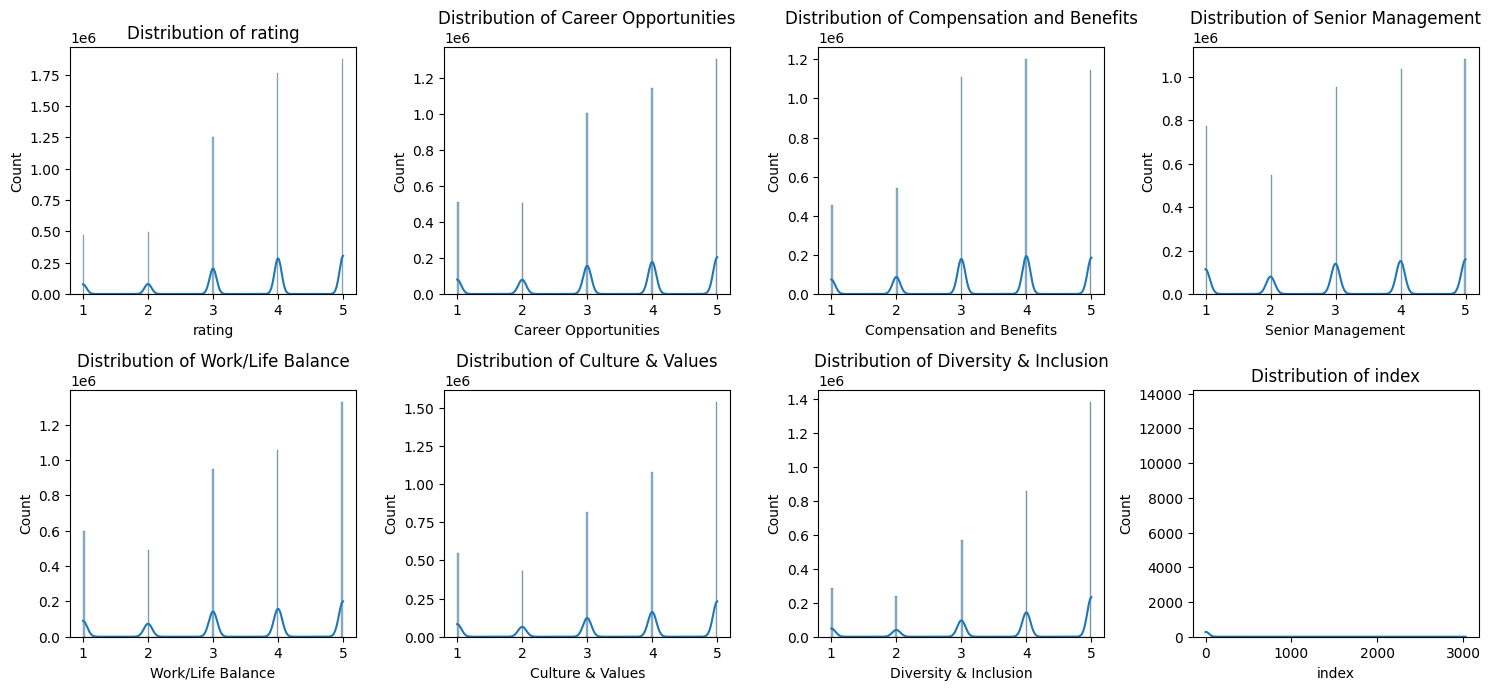

In [3]:
# Select numerical columns for distribution analysis
numerical_cols = df_attrition_merged.select_dtypes(include=np.number).columns.tolist()

# Exclude 'current' column if it was just created and not meant for this analysis, or if it's mostly NaNs
if 'current' in numerical_cols:
    numerical_cols.remove('current') # Assuming 'current' is a target or processed feature

# Create histograms for numerical columns
fig = plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_attrition_merged[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

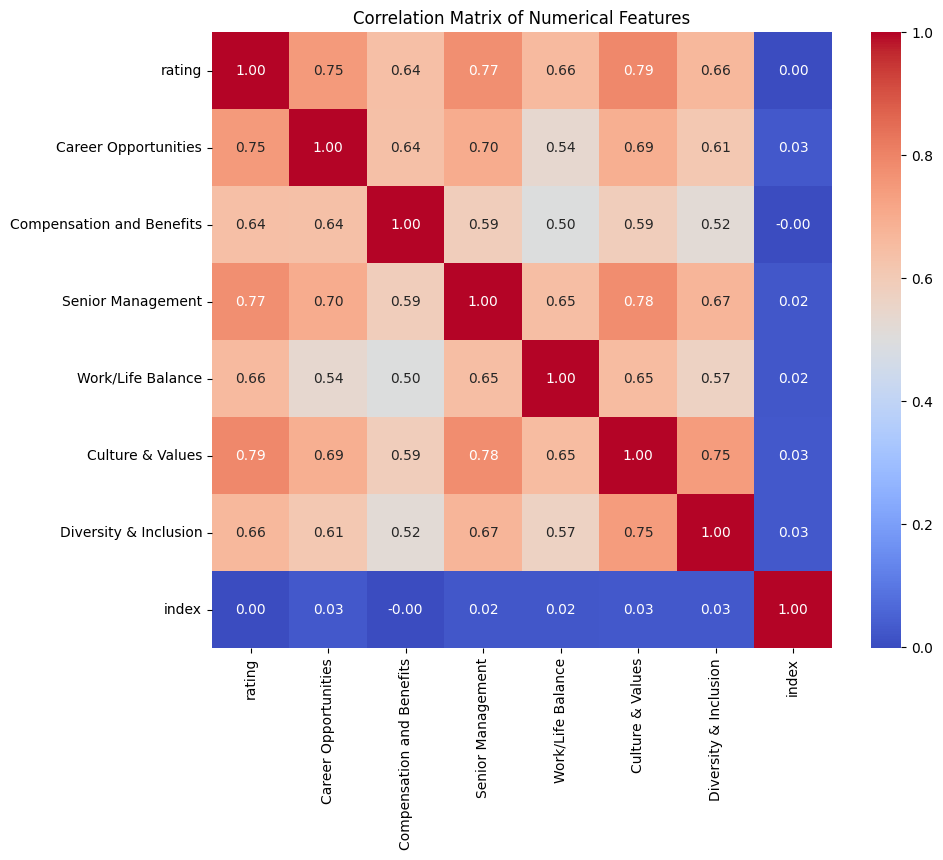

In [4]:
fig = plt.figure(figsize=(10, 8))
sns.heatmap(df_attrition_merged[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Distribution of Selected Categorical Features

/tmp/ipykernel_8842/4122508035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_attrition_merged, x=col, palette='viridis', order=df_attrition_merged[col].value_counts().index)
/tmp/ipykernel_8842/4122508035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_attrition_merged, x=col, palette='viridis', order=df_attrition_merged[col].value_counts().index)
/tmp/ipykernel_8842/4122508035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_attrition_merged, x=col, palette='viridis', order=df_attrition_merged[col]

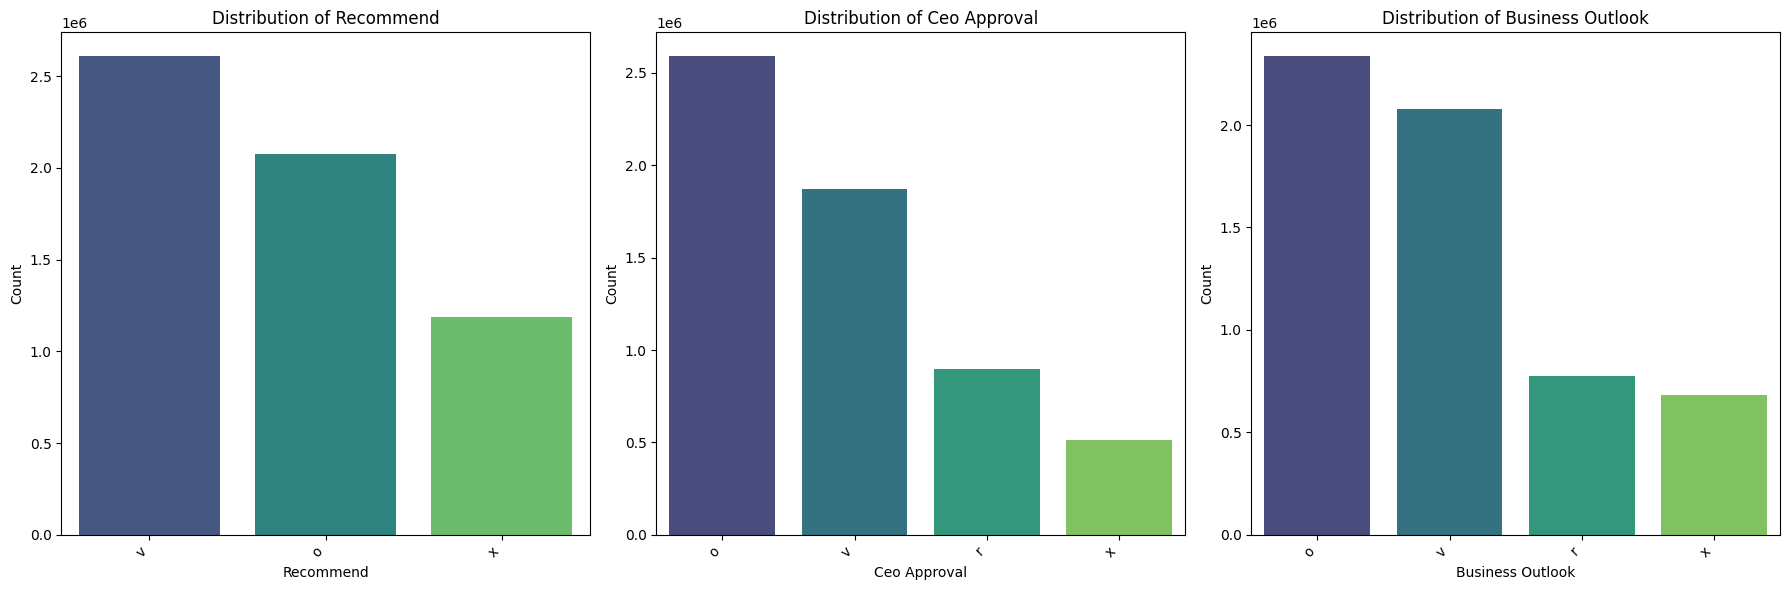

In [5]:
categorical_cols_to_plot = ['Recommend', 'CEO Approval', 'Business Outlook']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols_to_plot):
    if col in df_attrition_merged.columns:
        plt.subplot(1, 3, i + 1)
        sns.countplot(data=df_attrition_merged, x=col, palette='viridis', order=df_attrition_merged[col].value_counts().index)
        plt.title(f'Distribution of {col.replace("_", " ").title()}')
        plt.xlabel(col.replace("_", " ").title())
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")
plt.tight_layout()
plt.show()

### Checking for Missing Values

In [6]:
print('Missing values by column before cleaning:')
display(df_attrition_merged.isnull().sum())

Missing values by column before cleaning:


,0
rating,0
title,35247
status,0
pros,7
cons,18
advice,5872199
Recommend,0
CEO Approval,0
Business Outlook,0
Career Opportunities,1398785


In [7]:
print('Percentage of missing values by column:')
display(df_attrition_merged.isnull().sum() / len(df_attrition_merged) * 100)

Percentage of missing values by column:


,0
rating,0.000000
title,0.600234
status,0.000000
pros,0.000119
cons,0.000307
advice,99.999898
Recommend,0.000000
CEO Approval,0.000000
Business Outlook,0.000000
Career Opportunities,23.820439


This matrix visualizes the completeness of the dataset. Each row represents an observation, and each column represents a variable. The white lines indicate missing data points. A large white area in a column suggests a high number of missing values for that variable.

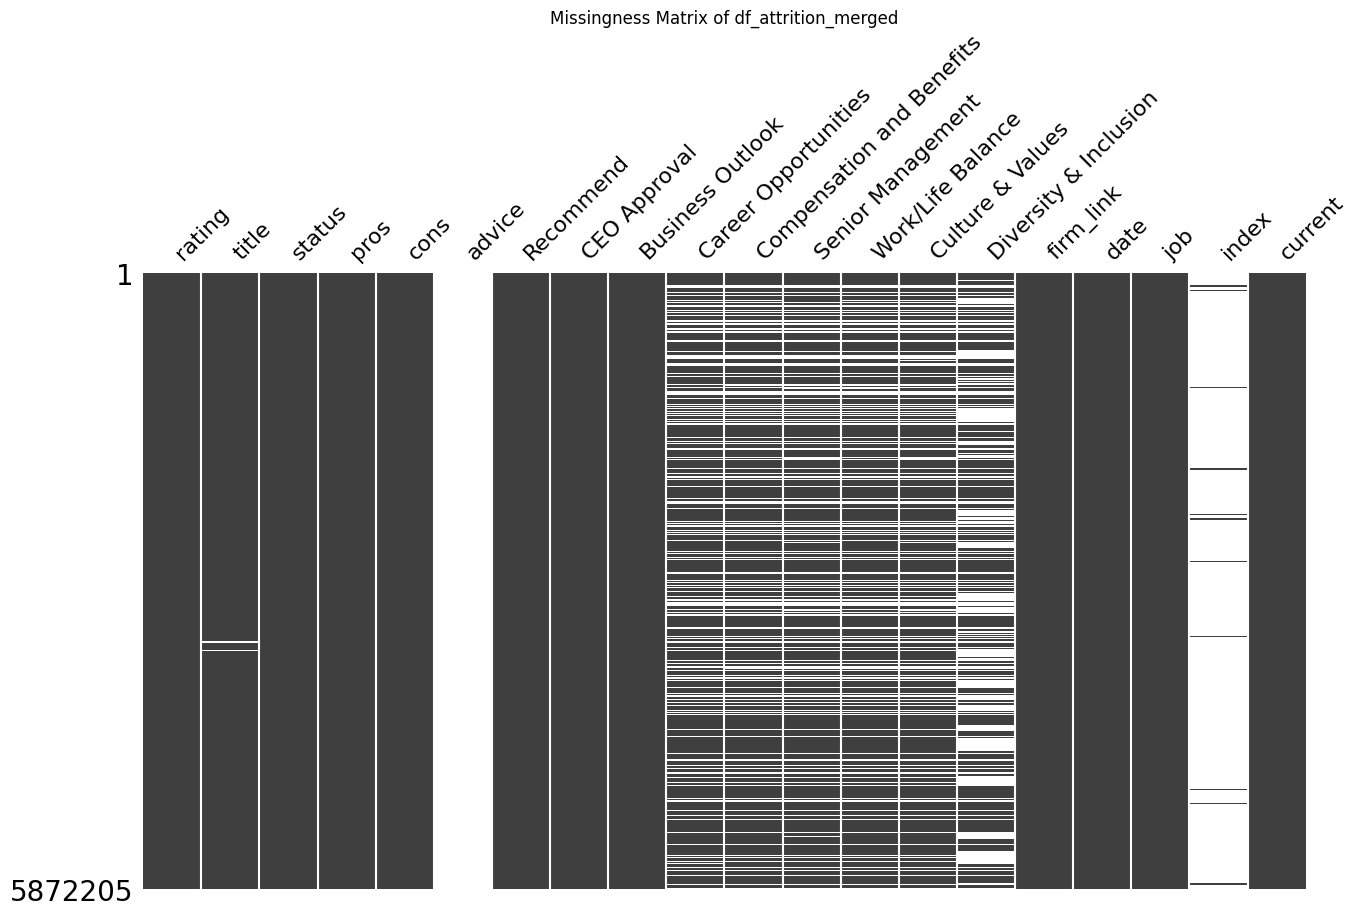

In [8]:
fig, ax = plt.subplots(figsize=(15, 8))
msno.matrix(df_attrition_merged, ax=ax, sparkline=False)
plt.title('Missingness Matrix of df_attrition_merged')
plt.show()

In [9]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# Select columns with significant missingness to test for MCAR
# Based on previous `isnull().sum()` output, 'Career Opportunities' (23.82%) and
# 'Diversity & Inclusion' (43.09%) are good candidates for this demonstration.
missing_check_cols = ['Career Opportunities', 'Diversity & Inclusion']

# Identify numerical and categorical columns for comparison
all_numerical_cols = df_attrition_merged.select_dtypes(include=np.number).columns.tolist()
# Remove 'current' and 'index' as they are either target or heavily missing and not suitable for comparison with other missingness
all_numerical_cols = [col for col in all_numerical_cols if col not in ['current', 'index', 'is_missing_career_opportunities', 'is_missing_diversity_inclusion']]

all_categorical_cols = df_attrition_merged.select_dtypes(include=['object', 'category']).columns.tolist()
# Remove highly granular/unique columns or those directly related to 'current' status, and the missing_check_cols themselves
exclude_from_cat_comparison = ['title', 'pros', 'cons', 'advice', 'firm_link', 'job', 'status']
all_categorical_cols = [col for col in all_categorical_cols if col not in exclude_from_cat_comparison]

print("Columns chosen for MCAR analysis (their missingness will be compared against other features):", missing_check_cols)
print("Numerical features used for comparison:", all_numerical_cols)
print("Categorical features used for comparison:", all_categorical_cols)

Columns chosen for MCAR analysis (their missingness will be compared against other features): ['Career Opportunities', 'Diversity & Inclusion']
Numerical features used for comparison: ['rating', 'Career Opportunities', 'Compensation and Benefits', 'Senior Management', 'Work/Life Balance', 'Culture & Values', 'Diversity & Inclusion']
Categorical features used for comparison: ['Recommend', 'CEO Approval', 'Business Outlook', 'date']


### MCAR Analysis for 'Career Opportunities' missingness

In [10]:
# Create a missingness indicator for 'Career Opportunities'
df_attrition_merged['is_missing_career_opportunities'] = df_attrition_merged['Career Opportunities'].isnull().astype(int)

mwu_co_results = []
print("\n--- Mann-Whitney U Test: Numerical Features vs. 'is_missing_career_opportunities' ---")
for num_col in all_numerical_cols:
    if num_col != 'Career Opportunities': # Don't compare a column's missingness with itself
        data_not_missing = df_attrition_merged[df_attrition_merged['is_missing_career_opportunities'] == 0][num_col].dropna()
        data_missing = df_attrition_merged[df_attrition_merged['is_missing_career_opportunities'] == 1][num_col].dropna()

        if len(data_not_missing) > 20 and len(data_missing) > 20:
            stat, p = stats.mannwhitneyu(data_not_missing, data_missing, alternative='two-sided')
            significance = 'Statistically significant (p < 0.05)' if p < 0.05 else 'Not significant (p >= 0.05)'
            mwu_co_results.append({
                'Feature': num_col,
                'Test': 'Mann-Whitney U',
                'Statistic': stat,
                'P-value': p,
                'Significance': significance
            })
            print(f"Feature: {num_col}")
            print(f"  U-statistic = {stat:.3f}, p-value = {p:.3f}")
            print(f"  -> {significance}")
        else:
            print(f"Feature: {num_col} - Not enough data in one or both groups to perform Mann-Whitney U test.")

chi2_co_results = []
print("\n--- Chi-Square Test: Categorical Features vs. 'is_missing_career_opportunities' ---")
for cat_col in all_categorical_cols:
    if cat_col != 'Career Opportunities': # Don't compare a column's missingness with itself
        contingency_table = pd.crosstab(df_attrition_merged[cat_col], df_attrition_merged['is_missing_career_opportunities'])
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 and contingency_table.min().min() > 0:
            chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
            significance = 'Statistically significant (p < 0.05)' if p < 0.05 else 'Not significant (p >= 0.05)'
            chi2_co_results.append({
                'Feature': cat_col,
                'Test': 'Chi-Square',
                'Statistic': chi2,
                'P-value': p,
                'Significance': significance
            })
            print(f"Feature: {cat_col}")
            print(f"  Chi2-statistic = {chi2:.3f}, p-value = {p:.3f}")
            print(f"  -> {significance}")
        else:
            print(f"Feature: {cat_col} - Contingency table too small or contains zero values for Chi-square test.")

df_mwu_co_results = pd.DataFrame(mwu_co_results)
df_chi2_co_results = pd.DataFrame(chi2_co_results)

print("\nMann-Whitney U Test Results for Career Opportunities missingness:")
display(df_mwu_co_results)
print("\nChi-Square Test Results for Career Opportunities missingness:")
display(df_chi2_co_results)


--- Mann-Whitney U Test: Numerical Features vs. 'is_missing_career_opportunities' ---
Feature: rating
  U-statistic = 2967815702119.000, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: Compensation and Benefits
  U-statistic = 50446066245.500, p-value = 0.878
  -> Not significant (p >= 0.05)
Feature: Senior Management
  U-statistic = 43939800046.000, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: Work/Life Balance
  U-statistic = 60817258687.500, p-value = 0.005
  -> Statistically significant (p < 0.05)
Feature: Culture & Values
  U-statistic = 50266819489.500, p-value = 0.016
  -> Statistically significant (p < 0.05)
Feature: Diversity & Inclusion
  U-statistic = 25215426638.500, p-value = 0.000
  -> Statistically significant (p < 0.05)

--- Chi-Square Test: Categorical Features vs. 'is_missing_career_opportunities' ---
Feature: Recommend
  Chi2-statistic = 2445336.845, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: CEO Appro

,Feature,Test,Statistic,P-value,Significance
0,rating,Mann-Whitney U,2.967816e+12,0.000000e+00,Statistically significant (p < 0.05)
1,Compensation and Benefits,Mann-Whitney U,5.044607e+10,8.780194e-01,Not significant (p >= 0.05)
2,Senior Management,Mann-Whitney U,4.393980e+10,2.964620e-73,Statistically significant (p < 0.05)
3,Work/Life Balance,Mann-Whitney U,6.081726e+10,5.214623e-03,Statistically significant (p < 0.05)
4,Culture & Values,Mann-Whitney U,5.026682e+10,1.572451e-02,Statistically significant (p < 0.05)
5,Diversity & Inclusion,Mann-Whitney U,2.521543e+10,3.991736e-05,Statistically significant (p < 0.05)



Chi-Square Test Results for Career Opportunities missingness:


,Feature,Test,Statistic,P-value,Significance
0,Recommend,Chi-Square,2.445337e+06,0.0,Statistically significant (p < 0.05)
1,CEO Approval,Chi-Square,1.770511e+06,0.0,Statistically significant (p < 0.05)
2,Business Outlook,Chi-Square,2.183873e+06,0.0,Statistically significant (p < 0.05)


### MCAR Analysis for 'Diversity & Inclusion' missingness

In [11]:
# Create a missingness indicator for 'Diversity & Inclusion'
df_attrition_merged['is_missing_diversity_inclusion'] = df_attrition_merged['Diversity & Inclusion'].isnull().astype(int)

mwu_di_results = []
print("\n--- Mann-Whitney U Test: Numerical Features vs. 'is_missing_diversity_inclusion' ---")
for num_col in all_numerical_cols:
    if num_col != 'Diversity & Inclusion': # Don't compare a column's missingness with itself
        data_not_missing = df_attrition_merged[df_attrition_merged['is_missing_diversity_inclusion'] == 0][num_col].dropna()
        data_missing = df_attrition_merged[df_attrition_merged['is_missing_diversity_inclusion'] == 1][num_col].dropna()

        if len(data_not_missing) > 20 and len(data_missing) > 20:
            stat, p = stats.mannwhitneyu(data_not_missing, data_missing, alternative='two-sided')
            significance = 'Statistically significant (p < 0.05)' if p < 0.05 else 'Not significant (p >= 0.05)'
            mwu_di_results.append({
                'Feature': num_col,
                'Test': 'Mann-Whitney U',
                'Statistic': stat,
                'P-value': p,
                'Significance': significance
            })
            print(f"Feature: {num_col}")
            print(f"  U-statistic = {stat:.3f}, p-value = {p:.3f}")
            print(f"  -> {significance}")
        else:
            print(f"Feature: {num_col} - Not enough data in one or both groups to perform Mann-Whitney U test.")

chi2_di_results = []
print("\n--- Chi-Square Test: Categorical Features vs. 'is_missing_diversity_inclusion' ---")
for cat_col in all_categorical_cols:
    if cat_col != 'Diversity & Inclusion': # Don't compare a column's missingness with itself
        contingency_table = pd.crosstab(df_attrition_merged[cat_col], df_attrition_merged['is_missing_diversity_inclusion'])
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 and contingency_table.min().min() > 0:
            chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
            significance = 'Statistically significant (p < 0.05)' if p < 0.05 else 'Not significant (p >= 0.05)'
            chi2_di_results.append({
                'Feature': cat_col,
                'Test': 'Chi-Square',
                'Statistic': chi2,
                'P-value': p,
                'Significance': significance
            })
            print(f"Feature: {cat_col}")
            print(f"  Chi2-statistic = {chi2:.3f}, p-value = {p:.3f}")
            print(f"  -> {significance}")
        else:
            print(f"Feature: {cat_col} - Contingency table too small or contains zero values for Chi-square test.")

df_mwu_di_results = pd.DataFrame(mwu_di_results)
df_chi2_di_results = pd.DataFrame(chi2_di_results)

print("\nMann-Whitney U Test Results for Diversity & Inclusion missingness:")
display(df_mwu_di_results)
print("\nChi-Square Test Results for Diversity & Inclusion missingness:")
display(df_chi2_di_results)


--- Mann-Whitney U Test: Numerical Features vs. 'is_missing_diversity_inclusion' ---
Feature: rating
  U-statistic = 4216037813464.000, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: Career Opportunities
  U-statistic = 2025141186016.500, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: Compensation and Benefits
  U-statistic = 1907465838721.000, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: Senior Management
  U-statistic = 1912813321538.000, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: Work/Life Balance
  U-statistic = 1865658719314.500, p-value = 0.000
  -> Statistically significant (p < 0.05)
Feature: Culture & Values
  U-statistic = 1906122980537.000, p-value = 0.000
  -> Statistically significant (p < 0.05)

--- Chi-Square Test: Categorical Features vs. 'is_missing_diversity_inclusion' ---
Feature: Recommend
  Chi2-statistic = 976117.194, p-value = 0.000
  -> Statistically significant (p < 0.05)
Fea

,Feature,Test,Statistic,P-value,Significance
0,rating,Mann-Whitney U,4.216038e+12,9.217573e-10,Statistically significant (p < 0.05)
1,Career Opportunities,Mann-Whitney U,2.025141e+12,0.000000e+00,Statistically significant (p < 0.05)
2,Compensation and Benefits,Mann-Whitney U,1.907466e+12,0.000000e+00,Statistically significant (p < 0.05)
3,Senior Management,Mann-Whitney U,1.912813e+12,0.000000e+00,Statistically significant (p < 0.05)
4,Work/Life Balance,Mann-Whitney U,1.865659e+12,4.405193e-182,Statistically significant (p < 0.05)
5,Culture & Values,Mann-Whitney U,1.906123e+12,0.000000e+00,Statistically significant (p < 0.05)



Chi-Square Test Results for Diversity & Inclusion missingness:


,Feature,Test,Statistic,P-value,Significance
0,Recommend,Chi-Square,976117.193867,0.0,Statistically significant (p < 0.05)
1,CEO Approval,Chi-Square,741831.290992,0.0,Statistically significant (p < 0.05)
2,Business Outlook,Chi-Square,857649.935045,0.0,Statistically significant (p < 0.05)


### Interpretation of MCAR Test Results

*   **If many p-values are less than 0.05:** This indicates that the missingness of the column being tested (e.g., 'Career Opportunities') is significantly related to the values of other observed features. In such cases, the data is likely **Missing At Random (MAR)** or **Missing Not At Random (NMAR)**, but not MCAR. This means that the missing data mechanism depends on observed data.
*   **If most p-values are greater than or equal to 0.05:** This suggests that there is no statistically significant relationship between the missingness of the column and the other observed features. This would support the assumption of **Missing Completely At Random (MCAR)** for that specific column's missingness.

### Exporting MCAR Test Results to CSV

In [12]:
import os

output_dir = './mcar_test_results'
os.makedirs(output_dir, exist_ok=True)

# Export Mann-Whitney U test results for Career Opportunities missingness
df_mwu_co_results.to_csv(f'{output_dir}/mwu_career_opportunities_mcar_results.csv', index=False)
print(f"Mann-Whitney U Test results for Career Opportunities saved to {output_dir}/mwu_career_opportunities_mcar_results.csv")

# Export Chi-Square test results for Career Opportunities missingness
df_chi2_co_results.to_csv(f'{output_dir}/chi2_career_opportunities_mcar_results.csv', index=False)
print(f"Chi-Square Test results for Career Opportunities saved to {output_dir}/chi2_career_opportunities_mcar_results.csv")

# Export Mann-Whitney U test results for Diversity & Inclusion missingness
df_mwu_di_results.to_csv(f'{output_dir}/mwu_diversity_inclusion_mcar_results.csv', index=False)
print(f"Mann-Whitney U Test results for Diversity & Inclusion saved to {output_dir}/mwu_diversity_inclusion_mcar_results.csv")

# Export Chi-Square test results for Diversity & Inclusion missingness
df_chi2_di_results.to_csv(f'{output_dir}/chi2_diversity_inclusion_mcar_results.csv', index=False)
print(f"Chi-Square Test results for Diversity & Inclusion saved to {output_dir}/chi2_diversity_inclusion_mcar_results.csv")

print("All MCAR test results have been exported.")

Mann-Whitney U Test results for Career Opportunities saved to ./mcar_test_results/mwu_career_opportunities_mcar_results.csv
Chi-Square Test results for Career Opportunities saved to ./mcar_test_results/chi2_career_opportunities_mcar_results.csv
Mann-Whitney U Test results for Diversity & Inclusion saved to ./mcar_test_results/mwu_diversity_inclusion_mcar_results.csv
Chi-Square Test results for Diversity & Inclusion saved to ./mcar_test_results/chi2_diversity_inclusion_mcar_results.csv
All MCAR test results have been exported.


### Exporting MCAR Test Results to CSV

In [13]:
import os

output_dir = './mcar_test_results'
os.makedirs(output_dir, exist_ok=True)

# Export Mann-Whitney U test results for Career Opportunities missingness
df_mwu_co_results.to_csv(f'{output_dir}/mwu_career_opportunities_mcar_results.csv', index=False)
print(f"Mann-Whitney U Test results for Career Opportunities saved to {output_dir}/mwu_career_opportunities_mcar_results.csv")

# Export Chi-Square test results for Career Opportunities missingness
df_chi2_co_results.to_csv(f'{output_dir}/chi2_career_opportunities_mcar_results.csv', index=False)
print(f"Chi-Square Test results for Career Opportunities saved to {output_dir}/chi2_career_opportunities_mcar_results.csv")

# Export Mann-Whitney U test results for Diversity & Inclusion missingness
df_mwu_di_results.to_csv(f'{output_dir}/mwu_diversity_inclusion_mcar_results.csv', index=False)
print(f"Mann-Whitney U Test results for Diversity & Inclusion saved to {output_dir}/mwu_diversity_inclusion_mcar_results.csv")

# Export Chi-Square test results for Diversity & Inclusion missingness
df_chi2_di_results.to_csv(f'{output_dir}/chi2_diversity_inclusion_mcar_results.csv', index=False)
print(f"Chi-Square Test results for Diversity & Inclusion saved to {output_dir}/chi2_diversity_inclusion_mcar_results.csv")

print("All MCAR test results have been exported.")

Mann-Whitney U Test results for Career Opportunities saved to ./mcar_test_results/mwu_career_opportunities_mcar_results.csv
Chi-Square Test results for Career Opportunities saved to ./mcar_test_results/chi2_career_opportunities_mcar_results.csv
Mann-Whitney U Test results for Diversity & Inclusion saved to ./mcar_test_results/mwu_diversity_inclusion_mcar_results.csv
Chi-Square Test results for Diversity & Inclusion saved to ./mcar_test_results/chi2_diversity_inclusion_mcar_results.csv
All MCAR test results have been exported.


### Removing Columns with High Missingness

In [14]:
# Calculate the percentage of missing values for each column
missing_percentages = df_attrition_merged.isnull().sum() / len(df_attrition_merged) * 100

# Define the missingness threshold
missingness_threshold = 26

# Identify columns to drop (those with missingness > threshold)
columns_to_drop = missing_percentages[missing_percentages > missingness_threshold].index.tolist()

print(f"Columns with more than {missingness_threshold}% missingness:\n{columns_to_drop}")

# Drop the identified columns from the DataFrame
df_attrition_merged_cleaned = df_attrition_merged.drop(columns=columns_to_drop)

print(f"\nOriginal DataFrame shape: {df_attrition_merged.shape}")
print(f"Cleaned DataFrame shape: {df_attrition_merged_cleaned.shape}")

df_attrition_merged = df_attrition_merged_cleaned

Columns with more than 26% missingness:
['advice', 'Diversity & Inclusion', 'index']

Original DataFrame shape: (5872205, 22)
Cleaned DataFrame shape: (5872205, 19)


### Missingness after dropping columns

In [15]:
print('Percentage of missing values by column after dropping high-missingness columns:')
display(df_attrition_merged.isnull().sum() / len(df_attrition_merged) * 100)

Percentage of missing values by column after dropping high-missingness columns:


,0
rating,0.000000
title,0.600234
status,0.000000
pros,0.000119
cons,0.000307
Recommend,0.000000
CEO Approval,0.000000
Business Outlook,0.000000
Career Opportunities,23.820439
Compensation and Benefits,24.281782


### Removing Rows with More Than One Missing Value

In [16]:
# Calculate the number of missing values for each row
missing_values_per_row = df_attrition_merged.isnull().sum(axis=1)

# Identify rows with more than 1 missing value
rows_to_drop = df_attrition_merged[missing_values_per_row > 1]

print(f"Number of rows with more than 1 missing value: {len(rows_to_drop)}")

# Drop these rows from the DataFrame
df_attrition_merged_rows_cleaned = df_attrition_merged[missing_values_per_row <= 1].copy()

print(f"\nOriginal DataFrame shape: {df_attrition_merged.shape}")
print(f"Cleaned DataFrame (rows) shape: {df_attrition_merged_rows_cleaned.shape}")

df_attrition_merged = df_attrition_merged_rows_cleaned

Number of rows with more than 1 missing value: 1463769

Original DataFrame shape: (5872205, 19)
Cleaned DataFrame (rows) shape: (4408436, 19)


### Missingness after dropping rows with more than 1 missing value

In [17]:
print('Percentage of missing values by column after dropping rows with more than 1 missing value:')
display(df_attrition_merged.isnull().sum() / len(df_attrition_merged) * 100)

Percentage of missing values by column after dropping rows with more than 1 missing value:


,0
rating,0.000000
title,0.445691
status,0.000000
pros,0.000159
cons,0.000318
Recommend,0.000000
CEO Approval,0.000000
Business Outlook,0.000000
Career Opportunities,0.272500
Compensation and Benefits,0.142772


### Removing All Remaining Rows with Any Missing Values

In [18]:
# Identify rows that still have any missing values
rows_with_any_missing = df_attrition_merged[df_attrition_merged.isnull().any(axis=1)]

print(f"Number of rows with at least one remaining missing value: {len(rows_with_any_missing)}")

# Drop these rows from the DataFrame
df_attrition_merged_final_cleaned = df_attrition_merged.dropna().copy()

print(f"\nOriginal DataFrame (after previous cleaning steps) shape: {df_attrition_merged.shape}")
print(f"Final Cleaned DataFrame shape: {df_attrition_merged_final_cleaned.shape}")

df_attrition_merged = df_attrition_merged_final_cleaned

Number of rows with at least one remaining missing value: 86078

Original DataFrame (after previous cleaning steps) shape: (4408436, 19)
Final Cleaned DataFrame shape: (4322358, 19)


### Final Missingness Check

In [19]:
print('Percentage of missing values by column after final cleaning:')
display(df_attrition_merged.isnull().sum() / len(df_attrition_merged) * 100)

Percentage of missing values by column after final cleaning:


,0
rating,0.0
title,0.0
status,0.0
pros,0.0
cons,0.0
Recommend,0.0
CEO Approval,0.0
Business Outlook,0.0
Career Opportunities,0.0
Compensation and Benefits,0.0


### Python Libraries and Their Versions

The table below lists the versions of the external Python libraries used in this notebook that are typically installed via `pip`. Modules that are part of Python's standard library (e.g., `os`, `re`, `collections`, `subprocess`) do not have individual `pip` versions; their functionality and version are tied to the Python interpreter itself.

In [49]:
import subprocess
import pandas as pd

def get_package_version(package_name):
    try:
        # Run pip show command and capture output
        result = subprocess.run(['pip', 'show', package_name], capture_output=True, text=True, check=True)
        output = result.stdout

        # Extract version from the output
        for line in output.splitlines():
            if line.startswith('Version:'):
                return line.split('Version:')[1].strip()
    except subprocess.CalledProcessError:
        return 'Not Installed or Built-in'
    except Exception as e:
        return f'Error: {e}'
    return 'Version not found'

# List of external libraries and packages imported/used in the notebook
libraries_to_check = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'plotly',
    'missingno',
    'nltk',
    'textblob',
    'wordcloud',
    'scipy',
    'scikit-learn' # The package name for sklearn
]

# Create a dictionary to store library names and their versions
versions_data = []
for lib in libraries_to_check:
    version = get_package_version(lib)
    versions_data.append({'Library': lib, 'Version': version})

# Create a DataFrame from the versions list and display it
df_all_versions = pd.DataFrame(versions_data)
display(df_all_versions)

,Library,Version
0,pandas,2.2.2
1,numpy,2.0.2
2,matplotlib,3.10.0
3,seaborn,0.13.2
4,plotly,5.24.1
5,missingno,0.5.2
6,nltk,3.9.1
7,textblob,0.20.1
8,wordcloud,1.9.6
9,scipy,1.16.3


### Outlier Detection for Numerical Features

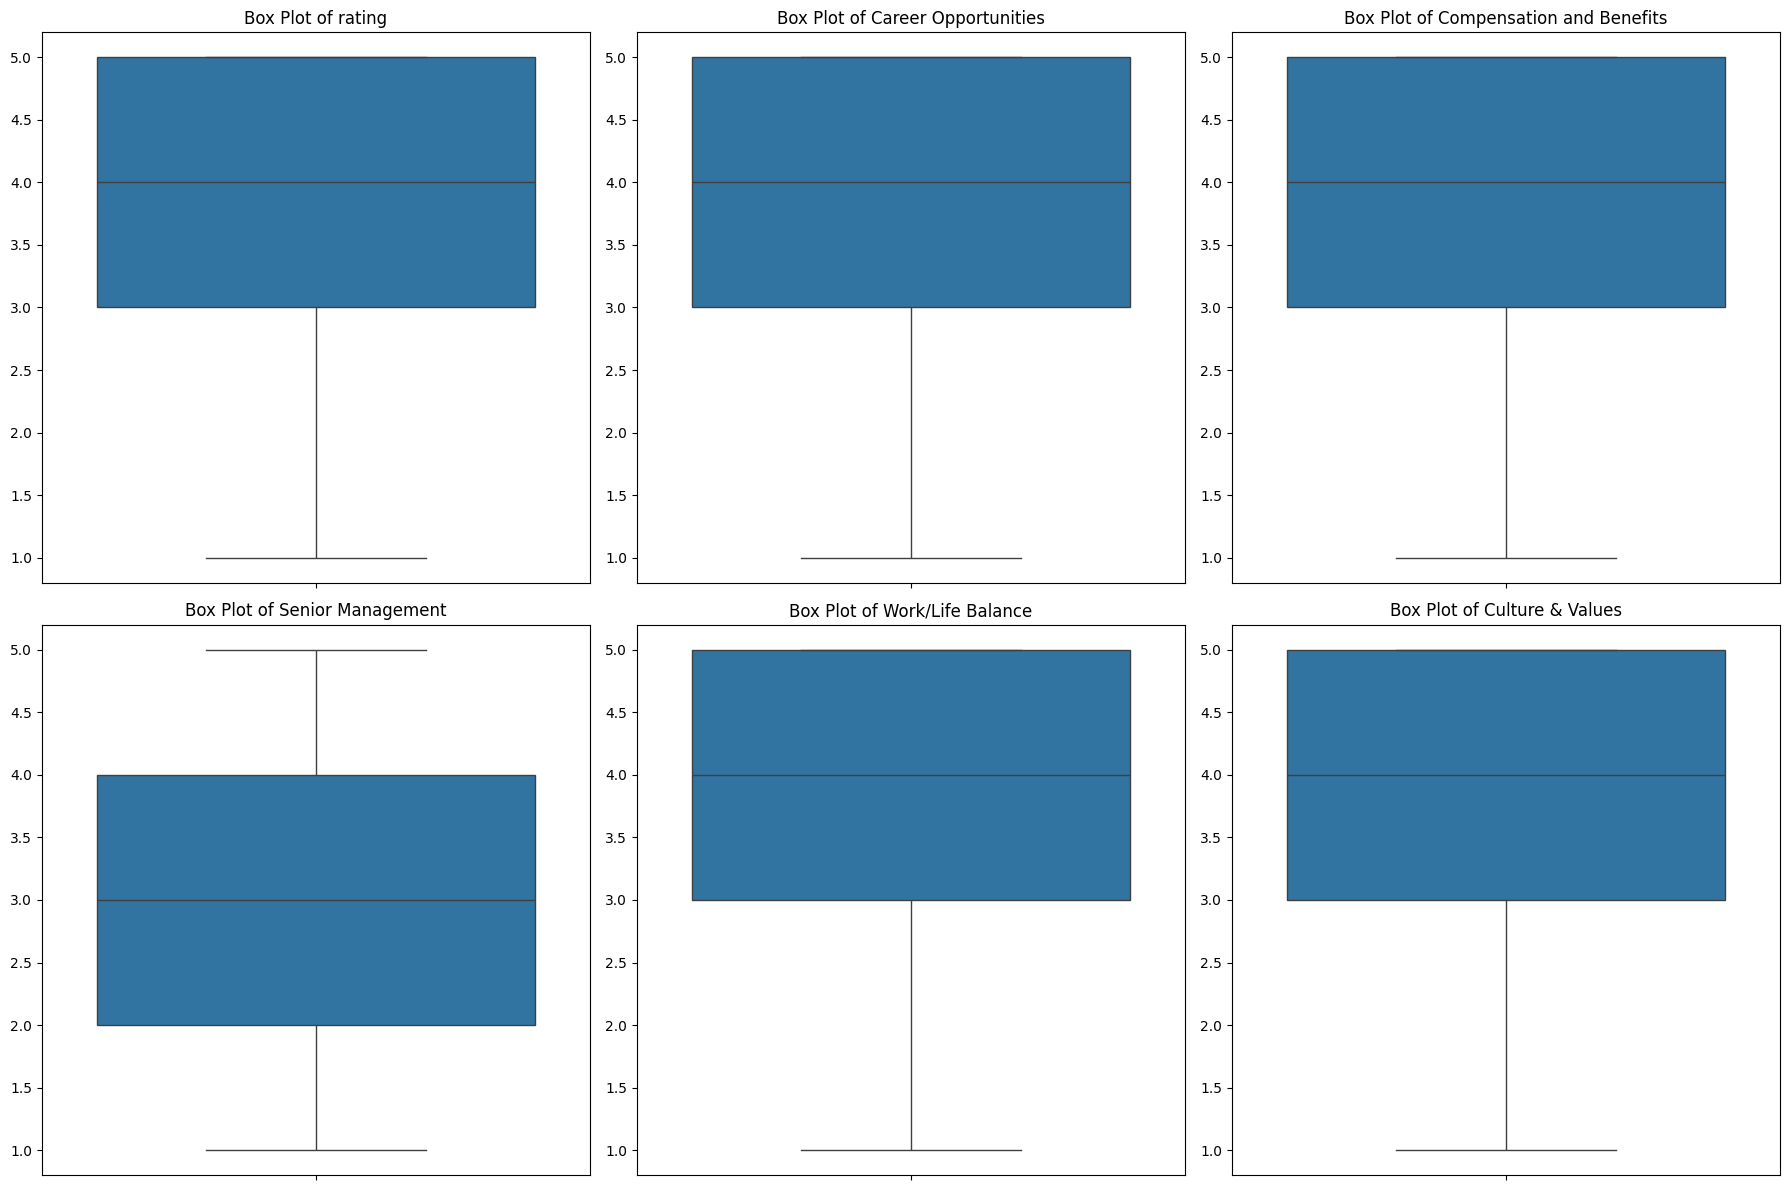

In [21]:
# Select numerical columns for outlier detection
# Exclude 'is_missing_...' columns as they are binary indicators, not continuous numerical features
# 'current' column is also a binary indicator
numerical_cols_for_outliers = [
    'rating',
    'Career Opportunities',
    'Compensation and Benefits',
    'Senior Management',
    'Work/Life Balance',
    'Culture & Values'
]

# Create box plots for each numerical column to visualize outliers
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_for_outliers):
    if col in df_attrition_merged.columns:
        sns.boxplot(y=df_attrition_merged[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel('')
    else:
        axes[i].set_visible(False) # Hide empty subplots if column not found

plt.tight_layout()
plt.show()

### Counting Rows with Identical Numerical Values

In [22]:
# Select numerical columns (excluding binary indicators if any, and other non-rating numerical columns like 'current', 'index')
# Reusing numerical_cols_for_outliers as they are the rating-based numerical columns

# Ensure these columns actually exist in the DataFrame after previous cleaning steps
valid_numerical_cols = [col for col in numerical_cols_for_outliers if col in df_attrition_merged.columns]

# Check if all values in these numerical columns are the same for each row
# This can be done by checking if the min and max value across these columns for a row are equal
rows_with_same_numerical_values = df_attrition_merged[valid_numerical_cols].apply(lambda x: x.min() == x.max(), axis=1)

# Count the number of such rows
count_same_numerical_values = rows_with_same_numerical_values.sum()

print(f"Number of rows where all selected numerical values are the same: {count_same_numerical_values}")

# If you want to see a sample of these rows
# display(df_attrition_merged[rows_with_same_numerical_values].head())

Number of rows where all selected numerical values are the same: 822619


### Omitting Rows with Identical Numerical Values

In [23]:
# Omit rows where all selected numerical values are the same
df_attrition_merged_no_identical_numerical_rows = df_attrition_merged[~rows_with_same_numerical_values].copy()

print(f"Original DataFrame shape (before omitting identical numerical rows): {df_attrition_merged.shape}")
print(f"New DataFrame shape (after omitting identical numerical rows): {df_attrition_merged_no_identical_numerical_rows.shape}")

df_attrition_merged = df_attrition_merged_no_identical_numerical_rows

Original DataFrame shape (before omitting identical numerical rows): (4322358, 19)
New DataFrame shape (after omitting identical numerical rows): (3499739, 19)


The DataFrame has been further cleaned by removing rows where all specified numerical features had identical values.

The box plots above show the distribution of each numerical feature and highlight any potential outliers as individual points beyond the 'whiskers' of the box plot. Given that most of these features are ratings on a scale (e.g., 1-5), values outside this common range might appear as outliers, but represent valid data points for these ordinal scales.

The DataFrame `df_attrition_merged` is now cleaned of columns with high missingness and all rows containing any missing values.

,Count,Percentage
current,,
0.0,2054632,58.71
1.0,1445107,41.29


/tmp/ipykernel_8842/3260720026.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=current_distribution.index, y=current_distribution['Count'], palette='viridis')


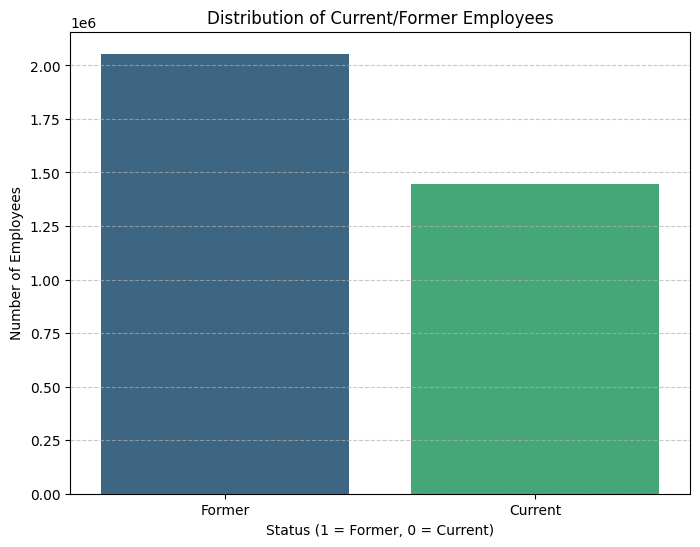

In [24]:
# Calculate value counts and percentages for the 'current' column; this allows for class imbalance
current_distribution = df_attrition_merged['current'].value_counts().to_frame(name='Count')
current_distribution['Percentage'] = (df_attrition_merged['current'].value_counts(normalize=True) * 100).round(2)

display(current_distribution)

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=current_distribution.index, y=current_distribution['Count'], palette='viridis')
plt.title('Distribution of Current/Former Employees')
plt.xlabel('Status (1 = Former, 0 = Current)')
plt.ylabel('Number of Employees')
plt.xticks(ticks=[0, 1], labels=['Former', 'Current'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [25]:
import pandas as pd

# Identify categorical columns suitable for one-hot encoding
categorical_cols_to_encode = [
    'Recommend',
    'CEO Approval',
    'Business Outlook'
]

# Perform one-hot encoding
df_attrition_merged = pd.get_dummies(
    df_attrition_merged,
    columns=categorical_cols_to_encode,
    drop_first=True, # Drop the first category to avoid multicollinearity
    dtype=int
)

print("DataFrame after one-hot encoding:")
df_attrition_merged.info()
print("\nFirst 5 rows of Merged DataFrame after one-hot encoding:")
display(df_attrition_merged.head())

DataFrame after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 24 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   rating                           float64
 1   title                            object 
 2   status                           object 
 3   pros                             object 
 4   cons                             object 
 5   Career Opportunities             float64
 6   Compensation and Benefits        float64
 7   Senior Management                float64
 8   Work/Life Balance                float64
 9   Culture & Values                 float64
 10  firm_link                        object 
 11  date                             object 
 12  job                              object 
 13  current                          float64
 14  is_missing_career_opportunities  int64  
 15  is_missing_diversity_inclusion   int64  
 16  Recommend_v              

,rating,title,status,pros,cons,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,...,is_missing_career_opportunities,is_missing_diversity_inclusion,Recommend_v,Recommend_x,CEO Approval_r,CEO Approval_v,CEO Approval_x,Business Outlook_r,Business Outlook_v,Business Outlook_x
0,5.0,Work hard but well looked after,"Current Employee, more than 3 years",Absa invests in their employees. We have a tra...,Audits occurs concurrently and so sometimes wo...,3.0,4.0,5.0,3.0,5.0,...,0,0,1,0,0,0,0,0,1,0
1,4.0,Work at absa,"Former Employee, more than 3 years",Paternity leave Paid leave Bonus,No work life balance No career progression,3.0,3.0,3.0,2.0,4.0,...,0,0,0,0,0,0,0,0,0,0
2,3.0,Absa,"Current Employee, more than 10 years",Job security and many opportunities,Big company with quite a top down management a...,4.0,4.0,2.0,2.0,3.0,...,0,0,0,0,0,0,0,0,0,0
3,4.0,work ethics,"Former Employee, less than 1 year",good company to work with,improve on customer experience and service,4.0,3.0,3.0,4.0,5.0,...,0,0,0,0,0,0,0,0,0,0
5,4.0,Absa Software Developer,"Current Employee, more than 3 years",Benefits are great in a bank,The company does not close in December,3.0,5.0,3.0,4.0,4.0,...,0,0,1,0,0,1,0,0,0,0


In [26]:
#droping features irrelevant to the study; title and firm link
columns_to_drop_after_encoding = ['title', 'firm_link']
df_attrition_merged = df_attrition_merged.drop(columns=columns_to_drop_after_encoding, errors='ignore')

print("DataFrame after dropping 'title' and 'firm_link' columns:")
df_attrition_merged.info()
print("\nFirst 5 rows of Merged DataFrame after dropping columns:")
display(df_attrition_merged.head())

DataFrame after dropping 'title' and 'firm_link' columns:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 22 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   rating                           float64
 1   status                           object 
 2   pros                             object 
 3   cons                             object 
 4   Career Opportunities             float64
 5   Compensation and Benefits        float64
 6   Senior Management                float64
 7   Work/Life Balance                float64
 8   Culture & Values                 float64
 9   date                             object 
 10  job                              object 
 11  current                          float64
 12  is_missing_career_opportunities  int64  
 13  is_missing_diversity_inclusion   int64  
 14  Recommend_v                      int64  
 15  Recommend_x                      int64  
 16  C

,rating,status,pros,cons,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,date,...,is_missing_career_opportunities,is_missing_diversity_inclusion,Recommend_v,Recommend_x,CEO Approval_r,CEO Approval_v,CEO Approval_x,Business Outlook_r,Business Outlook_v,Business Outlook_x
0,5.0,"Current Employee, more than 3 years",Absa invests in their employees. We have a tra...,Audits occurs concurrently and so sometimes wo...,3.0,4.0,5.0,3.0,5.0,2022-09-20,...,0,0,1,0,0,0,0,0,1,0
1,4.0,"Former Employee, more than 3 years",Paternity leave Paid leave Bonus,No work life balance No career progression,3.0,3.0,3.0,2.0,4.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
2,3.0,"Current Employee, more than 10 years",Job security and many opportunities,Big company with quite a top down management a...,4.0,4.0,2.0,2.0,3.0,2022-11-20,...,0,0,0,0,0,0,0,0,0,0
3,4.0,"Former Employee, less than 1 year",good company to work with,improve on customer experience and service,4.0,3.0,3.0,4.0,5.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
5,4.0,"Current Employee, more than 3 years",Benefits are great in a bank,The company does not close in December,3.0,5.0,3.0,4.0,4.0,2022-11-13,...,0,0,1,0,0,1,0,0,0,0


In [27]:
# Define the renaming dictionary
rename_dict = {
    'Recommend_v': 'recommend_positive',
    'Recommend_x': 'recommend_negative',
    'Recommend_o': 'recommend_no_opinion',
    'CEO Approval_v': 'ceo_approv_positive',
    'CEO Approval_x': 'ceo_approv_negative',
    'CEO Approval_o': 'ceo_approv_no_opinion',
    'CEO Approval_r': 'ceo_approv_mild',
    'Business Outlook_v': 'outlook_positive',
    'Business Outlook_x': 'outlook_negative',
    'Business Outlook_o': 'outlook_no_opinion',
    'Business Outlook_r': 'outlook_mild'
}

# Rename the columns in df_attrition_merged
df_attrition_merged = df_attrition_merged.rename(columns=rename_dict)

# Display the head of the DataFrame with the renamed columns
print("\nDataFrame head after renaming columns:")
display(df_attrition_merged.head())


DataFrame head after renaming columns:


,rating,status,pros,cons,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,date,...,is_missing_career_opportunities,is_missing_diversity_inclusion,recommend_positive,recommend_negative,ceo_approv_mild,ceo_approv_positive,ceo_approv_negative,outlook_mild,outlook_positive,outlook_negative
0,5.0,"Current Employee, more than 3 years",Absa invests in their employees. We have a tra...,Audits occurs concurrently and so sometimes wo...,3.0,4.0,5.0,3.0,5.0,2022-09-20,...,0,0,1,0,0,0,0,0,1,0
1,4.0,"Former Employee, more than 3 years",Paternity leave Paid leave Bonus,No work life balance No career progression,3.0,3.0,3.0,2.0,4.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
2,3.0,"Current Employee, more than 10 years",Job security and many opportunities,Big company with quite a top down management a...,4.0,4.0,2.0,2.0,3.0,2022-11-20,...,0,0,0,0,0,0,0,0,0,0
3,4.0,"Former Employee, less than 1 year",good company to work with,improve on customer experience and service,4.0,3.0,3.0,4.0,5.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
5,4.0,"Current Employee, more than 3 years",Benefits are great in a bank,The company does not close in December,3.0,5.0,3.0,4.0,4.0,2022-11-13,...,0,0,1,0,0,1,0,0,0,0


In [28]:
import re

# Define keywords for executive roles
executive_keywords = ['CEO', 'CFO', 'CIO', 'President']

# Create a regex pattern to match any of the keywords as whole words
# The \b ensures word boundaries, so 'President' doesn't match 'Vice President' incidentally if not desired.
# If you want to match 'Vice President' too, you can remove \b.
pattern = r'\b(?:' + '|'.join(executive_keywords) + r')\b'

# Create the 'executive' column
df_attrition_merged['executive'] = df_attrition_merged['job'].fillna('').apply(lambda x: 1 if re.search(pattern, x, re.IGNORECASE) else 0)

print("DataFrame after creating 'executive' column:")
df_attrition_merged.info()
print("\nFirst 5 rows of Merged DataFrame after 'executive' transformation:")
display(df_attrition_merged.head())

DataFrame after creating 'executive' column:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 23 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   rating                           float64
 1   status                           object 
 2   pros                             object 
 3   cons                             object 
 4   Career Opportunities             float64
 5   Compensation and Benefits        float64
 6   Senior Management                float64
 7   Work/Life Balance                float64
 8   Culture & Values                 float64
 9   date                             object 
 10  job                              object 
 11  current                          float64
 12  is_missing_career_opportunities  int64  
 13  is_missing_diversity_inclusion   int64  
 14  recommend_positive               int64  
 15  recommend_negative               int64  
 16  ceo_approv_mil

,rating,status,pros,cons,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,date,...,is_missing_diversity_inclusion,recommend_positive,recommend_negative,ceo_approv_mild,ceo_approv_positive,ceo_approv_negative,outlook_mild,outlook_positive,outlook_negative,executive
0,5.0,"Current Employee, more than 3 years",Absa invests in their employees. We have a tra...,Audits occurs concurrently and so sometimes wo...,3.0,4.0,5.0,3.0,5.0,2022-09-20,...,0,1,0,0,0,0,0,1,0,0
1,4.0,"Former Employee, more than 3 years",Paternity leave Paid leave Bonus,No work life balance No career progression,3.0,3.0,3.0,2.0,4.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
2,3.0,"Current Employee, more than 10 years",Job security and many opportunities,Big company with quite a top down management a...,4.0,4.0,2.0,2.0,3.0,2022-11-20,...,0,0,0,0,0,0,0,0,0,0
3,4.0,"Former Employee, less than 1 year",good company to work with,improve on customer experience and service,4.0,3.0,3.0,4.0,5.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
5,4.0,"Current Employee, more than 3 years",Benefits are great in a bank,The company does not close in December,3.0,5.0,3.0,4.0,4.0,2022-11-13,...,0,1,0,0,1,0,0,0,0,0


In [29]:
# Create 'senior_leadership' column based on 'Director' in job title
df_attrition_merged['senior_leadership'] = df_attrition_merged['job'].fillna('').apply(lambda x: 1 if 'Director' in x else 0)

print("DataFrame after creating 'senior_leadership' column:")
df_attrition_merged.info()
print("\nFirst 5 rows of Merged DataFrame after 'senior_leadership' transformation:")
display(df_attrition_merged.head())

DataFrame after creating 'senior_leadership' column:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 24 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   rating                           float64
 1   status                           object 
 2   pros                             object 
 3   cons                             object 
 4   Career Opportunities             float64
 5   Compensation and Benefits        float64
 6   Senior Management                float64
 7   Work/Life Balance                float64
 8   Culture & Values                 float64
 9   date                             object 
 10  job                              object 
 11  current                          float64
 12  is_missing_career_opportunities  int64  
 13  is_missing_diversity_inclusion   int64  
 14  recommend_positive               int64  
 15  recommend_negative               int64  
 16  ceo_ap

,rating,status,pros,cons,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,date,...,recommend_positive,recommend_negative,ceo_approv_mild,ceo_approv_positive,ceo_approv_negative,outlook_mild,outlook_positive,outlook_negative,executive,senior_leadership
0,5.0,"Current Employee, more than 3 years",Absa invests in their employees. We have a tra...,Audits occurs concurrently and so sometimes wo...,3.0,4.0,5.0,3.0,5.0,2022-09-20,...,1,0,0,0,0,0,1,0,0,0
1,4.0,"Former Employee, more than 3 years",Paternity leave Paid leave Bonus,No work life balance No career progression,3.0,3.0,3.0,2.0,4.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
2,3.0,"Current Employee, more than 10 years",Job security and many opportunities,Big company with quite a top down management a...,4.0,4.0,2.0,2.0,3.0,2022-11-20,...,0,0,0,0,0,0,0,0,0,0
3,4.0,"Former Employee, less than 1 year",good company to work with,improve on customer experience and service,4.0,3.0,3.0,4.0,5.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
5,4.0,"Current Employee, more than 3 years",Benefits are great in a bank,The company does not close in December,3.0,5.0,3.0,4.0,4.0,2022-11-13,...,1,0,0,1,0,0,0,0,0,0


In [30]:
import re

# Define keywords for leadership roles (supervisor/manager and variations)
leadership_keywords = [
    'supervisor', 'supervising', 'supervidor', 'supervisior', 'supervior', 'superisor',
    'supervsior', 'superivsor', 'supervised', 'superwiser', 'supervor', 'superviseur',
    'supervizor', 'supervispr', 'super visor', 'superrvisor', 'superviors', 'superviseure',
    'supervisosr', 'supersivor', 'superviser', 'supervisir', 'supervusor', 'supervise',
    'supervisot', 'superving', 'ssuperisor', 'superior', 'supervsieo', 'manager'
]

# Create a regex pattern to match any of the keywords
# Using word boundaries (\b) for more precise matching, but removing it for some variations like 'supervising'
# or if 'manager' should match 'Assistant Manager'
# For broad matching, it's safer to not use \b for all terms.
pattern = r'(?i)' + '|'.join(leadership_keywords)

# Create the 'leadership' column
df_attrition_merged['leadership'] = df_attrition_merged['job'].fillna('').apply(lambda x: 1 if re.search(pattern, x) else 0)

print("DataFrame after creating 'leadership' column:")
df_attrition_merged.info()
print("\nFirst 5 rows of Merged DataFrame after 'leadership' transformation:")
display(df_attrition_merged.head())

DataFrame after creating 'leadership' column:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 25 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   rating                           float64
 1   status                           object 
 2   pros                             object 
 3   cons                             object 
 4   Career Opportunities             float64
 5   Compensation and Benefits        float64
 6   Senior Management                float64
 7   Work/Life Balance                float64
 8   Culture & Values                 float64
 9   date                             object 
 10  job                              object 
 11  current                          float64
 12  is_missing_career_opportunities  int64  
 13  is_missing_diversity_inclusion   int64  
 14  recommend_positive               int64  
 15  recommend_negative               int64  
 16  ceo_approv_mi

,rating,status,pros,cons,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,date,...,recommend_negative,ceo_approv_mild,ceo_approv_positive,ceo_approv_negative,outlook_mild,outlook_positive,outlook_negative,executive,senior_leadership,leadership
0,5.0,"Current Employee, more than 3 years",Absa invests in their employees. We have a tra...,Audits occurs concurrently and so sometimes wo...,3.0,4.0,5.0,3.0,5.0,2022-09-20,...,0,0,0,0,0,1,0,0,0,0
1,4.0,"Former Employee, more than 3 years",Paternity leave Paid leave Bonus,No work life balance No career progression,3.0,3.0,3.0,2.0,4.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
2,3.0,"Current Employee, more than 10 years",Job security and many opportunities,Big company with quite a top down management a...,4.0,4.0,2.0,2.0,3.0,2022-11-20,...,0,0,0,0,0,0,0,0,0,0
3,4.0,"Former Employee, less than 1 year",good company to work with,improve on customer experience and service,4.0,3.0,3.0,4.0,5.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,0
5,4.0,"Current Employee, more than 3 years",Benefits are great in a bank,The company does not close in December,3.0,5.0,3.0,4.0,4.0,2022-11-13,...,0,0,1,0,0,0,0,0,0,0


In [31]:
# Create 'individual_contributor' column
# A job is considered an 'individual_contributor' if it's not executive, senior_leadership, or leadership
df_attrition_merged['individual_contributor'] = (
    (df_attrition_merged['executive'] == 0) &
    (df_attrition_merged['senior_leadership'] == 0) &
    (df_attrition_merged['leadership'] == 0)
).astype(int)

print("DataFrame after creating 'individual_contributor' column:")
df_attrition_merged.info()
print("\nFirst 5 rows of Merged DataFrame after 'individual_contributor' transformation:")
display(df_attrition_merged.head())

DataFrame after creating 'individual_contributor' column:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 26 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   rating                           float64
 1   status                           object 
 2   pros                             object 
 3   cons                             object 
 4   Career Opportunities             float64
 5   Compensation and Benefits        float64
 6   Senior Management                float64
 7   Work/Life Balance                float64
 8   Culture & Values                 float64
 9   date                             object 
 10  job                              object 
 11  current                          float64
 12  is_missing_career_opportunities  int64  
 13  is_missing_diversity_inclusion   int64  
 14  recommend_positive               int64  
 15  recommend_negative               int64  
 16  c

,rating,status,pros,cons,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,date,...,ceo_approv_mild,ceo_approv_positive,ceo_approv_negative,outlook_mild,outlook_positive,outlook_negative,executive,senior_leadership,leadership,individual_contributor
0,5.0,"Current Employee, more than 3 years",Absa invests in their employees. We have a tra...,Audits occurs concurrently and so sometimes wo...,3.0,4.0,5.0,3.0,5.0,2022-09-20,...,0,0,0,0,1,0,0,0,0,1
1,4.0,"Former Employee, more than 3 years",Paternity leave Paid leave Bonus,No work life balance No career progression,3.0,3.0,3.0,2.0,4.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,1
2,3.0,"Current Employee, more than 10 years",Job security and many opportunities,Big company with quite a top down management a...,4.0,4.0,2.0,2.0,3.0,2022-11-20,...,0,0,0,0,0,0,0,0,0,1
3,4.0,"Former Employee, less than 1 year",good company to work with,improve on customer experience and service,4.0,3.0,3.0,4.0,5.0,2022-11-16,...,0,0,0,0,0,0,0,0,0,1
5,4.0,"Current Employee, more than 3 years",Benefits are great in a bank,The company does not close in December,3.0,5.0,3.0,4.0,4.0,2022-11-13,...,0,1,0,0,0,0,0,0,0,1


In [32]:
# Convert 'date' column to datetime objects if not already converted
df_attrition_merged['date'] = pd.to_datetime(df_attrition_merged['date'])

# Extract year
df_attrition_merged['year'] = df_attrition_merged['date'].dt.year

# Extract month
df_attrition_merged['month'] = df_attrition_merged['date'].dt.month

# Extract day of week (Monday=0, Sunday=6)
df_attrition_merged['day_of_week'] = df_attrition_merged['date'].dt.dayofweek

print("DataFrame after extracting year, month, and day of week:")
df_attrition_merged.info()
print("\nFirst 5 rows of Merged DataFrame with new date features:")
display(df_attrition_merged[['date', 'year', 'month', 'day_of_week']].head())

DataFrame after extracting year, month, and day of week:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 29 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   rating                           float64       
 1   status                           object        
 2   pros                             object        
 3   cons                             object        
 4   Career Opportunities             float64       
 5   Compensation and Benefits        float64       
 6   Senior Management                float64       
 7   Work/Life Balance                float64       
 8   Culture & Values                 float64       
 9   date                             datetime64[ns]
 10  job                              object        
 11  current                          float64       
 12  is_missing_career_opportunities  int64         
 13  is_missing_diversity_inclusion   in

,date,year,month,day_of_week
0,2022-09-20,2022,9,1
1,2022-11-16,2022,11,2
2,2022-11-20,2022,11,6
3,2022-11-16,2022,11,2
5,2022-11-13,2022,11,6


### Distribution of Date Features (Year, Month, Day of Week)

/tmp/ipykernel_8842/1531014792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_attrition_merged, x='year', palette='viridis', ax=axes[0])
/tmp/ipykernel_8842/1531014792.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_attrition_merged, x='month', palette='viridis', ax=axes[1])
/tmp/ipykernel_8842/1531014792.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_attrition_merged, x='day_of_week', palette='viridis', ax=axes[2])
/tmp/ipykernel_8842/1531014792.py:28: UserWarning: set_ticklabels() should only b

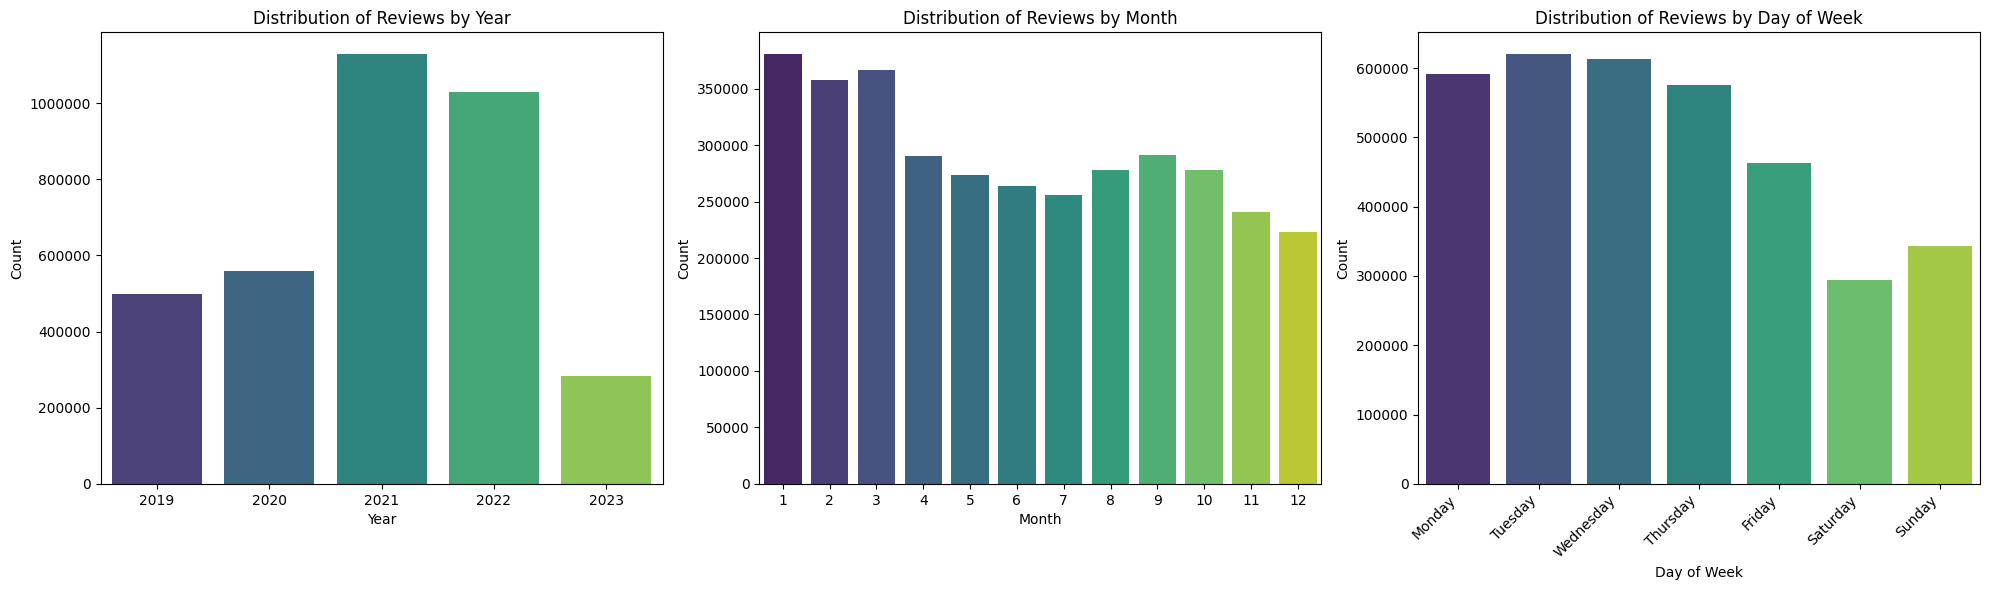

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot distribution of 'year'
sns.countplot(data=df_attrition_merged, x='year', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Reviews by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].ticklabel_format(axis='y', style='plain')

# Plot distribution of 'month'
sns.countplot(data=df_attrition_merged, x='month', palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Reviews by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].ticklabel_format(axis='y', style='plain')

# Plot distribution of 'day_of_week'
# Map day of week numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_attrition_merged, x='day_of_week', palette='viridis', ax=axes[2])
axes[2].set_title('Distribution of Reviews by Day of Week')
axes[2].set_xlabel('Day of Week')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(day_names, rotation=45, ha='right')
axes[2].ticklabel_format(axis='y', style='plain')

plt.tight_layout()
plt.show()

In [34]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import pandas as pd

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define a preprocessing function
def preprocess_text(text):
    if pd.isna(text) or text is None:
        return ""
    text = text.lower()
    tokens = word_tokenize(text)
    processed_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words:
            stemmed_word = stemmer.stem(word)
            lemmatized_word = lemmatizer.lemmatize(stemmed_word)
            processed_tokens.append(lemmatized_word)
    return ' '.join(processed_tokens)

print("Applying preprocessing to 'pros' column...")
df_attrition_merged['pros_processed'] = df_attrition_merged['pros'].apply(preprocess_text)
print("Applying preprocessing to 'cons' column...")
df_attrition_merged['cons_processed'] = df_attrition_merged['cons'].apply(preprocess_text)

print("DataFrame after text preprocessing:")
df_attrition_merged.info()
print("\nSample of 'pros', 'pros_processed', 'cons', and 'cons_processed' columns:")
display(df_attrition_merged[['pros', 'pros_processed', 'cons', 'cons_processed']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Applying preprocessing to 'pros' column...
Applying preprocessing to 'cons' column...
DataFrame after text preprocessing:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 31 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   rating                           float64       
 1   status                           object        
 2   pros                             object        
 3   cons                             object        
 4   Career Opportunities             float64       
 5   Compensation and Benefits        float64       
 6   Senior Management                float64       
 7   Work/Life Balance                float64       
 8   Culture & Values                 float64       
 9   date                             datetime64[ns]
 10  job                              object        
 11  current                          float64       
 12  is_missing_career_oppor

,pros,pros_processed,cons,cons_processed
0,Absa invests in their employees. We have a tra...,absa invest employe train budget everi year ex...,Audits occurs concurrently and so sometimes wo...,audit occur concurr sometim workload quit lot
1,Paternity leave Paid leave Bonus,patern leav paid leav bonu,No work life balance No career progression,work life balanc career progress
2,Job security and many opportunities,job secur mani opportun,Big company with quite a top down management a...,big compani quit top manag approach
3,good company to work with,good compani work,improve on customer experience and service,improv custom experi servic
5,Benefits are great in a bank,benefit great bank,The company does not close in December,compani close decemb


### Sentiment Analysis using TextBlob

In [35]:
!pip install textblob
import pandas as pd
from textblob import TextBlob

# Function to get sentiment polarity and subjectivity
def get_sentiment(text):
    if pd.isna(text) or text == "":
        return None, None
    analysis = TextBlob(text)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

# Apply sentiment analysis to 'pros_processed' column
print("Applying sentiment analysis to 'pros_processed' column...")
df_attrition_merged['pros_polarity'], df_attrition_merged['pros_subjectivity'] = zip(*df_attrition_merged['pros_processed'].apply(get_sentiment))

# Apply sentiment analysis to 'cons_processed' column
print("Applying sentiment analysis to 'cons_processed' column...")
df_attrition_merged['cons_polarity'], df_attrition_merged['cons_subjectivity'] = zip(*df_attrition_merged['cons_processed'].apply(get_sentiment))

print("DataFrame after sentiment analysis:")
df_attrition_merged.info()
print("\nSample of sentiment analysis results:")
display(df_attrition_merged[['pros_processed', 'pros_polarity', 'pros_subjectivity', 'cons_processed', 'cons_polarity', 'cons_subjectivity']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 22.9 MB/s eta 0:00:00
Applying sentiment analysis to 'pros_processed' column...
Applying sentiment analysis to 'cons_processed' column...
DataFrame after sentiment analysis:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 35 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   rating                           float64       
 1   status                           object        
 2   pros                             object        
 3   cons                             object        
 4   Career Opportunities             float64       
 5   Compensation and Benefits        float64       
 6   Senior Management                float64       
 7   Work/Life Balance                float64       
 8   Culture & Values                 float64       
 9   date                             datetime64[ns]
 10  job               

,pros_processed,pros_polarity,pros_subjectivity,cons_processed,cons_polarity,cons_subjectivity
0,absa invest employe train budget everi year ex...,0.8,0.75,audit occur concurr sometim workload quit lot,0.00,0.0
1,patern leav paid leav bonu,0.0,0.00,work life balanc career progress,0.00,0.0
2,job secur mani opportun,0.0,0.00,big compani quit top manag approach,0.25,0.3
3,good compani work,0.7,0.60,improv custom experi servic,0.00,0.0
5,benefit great bank,0.8,0.75,compani close decemb,0.00,0.0


### Distribution of Sentiment Scores

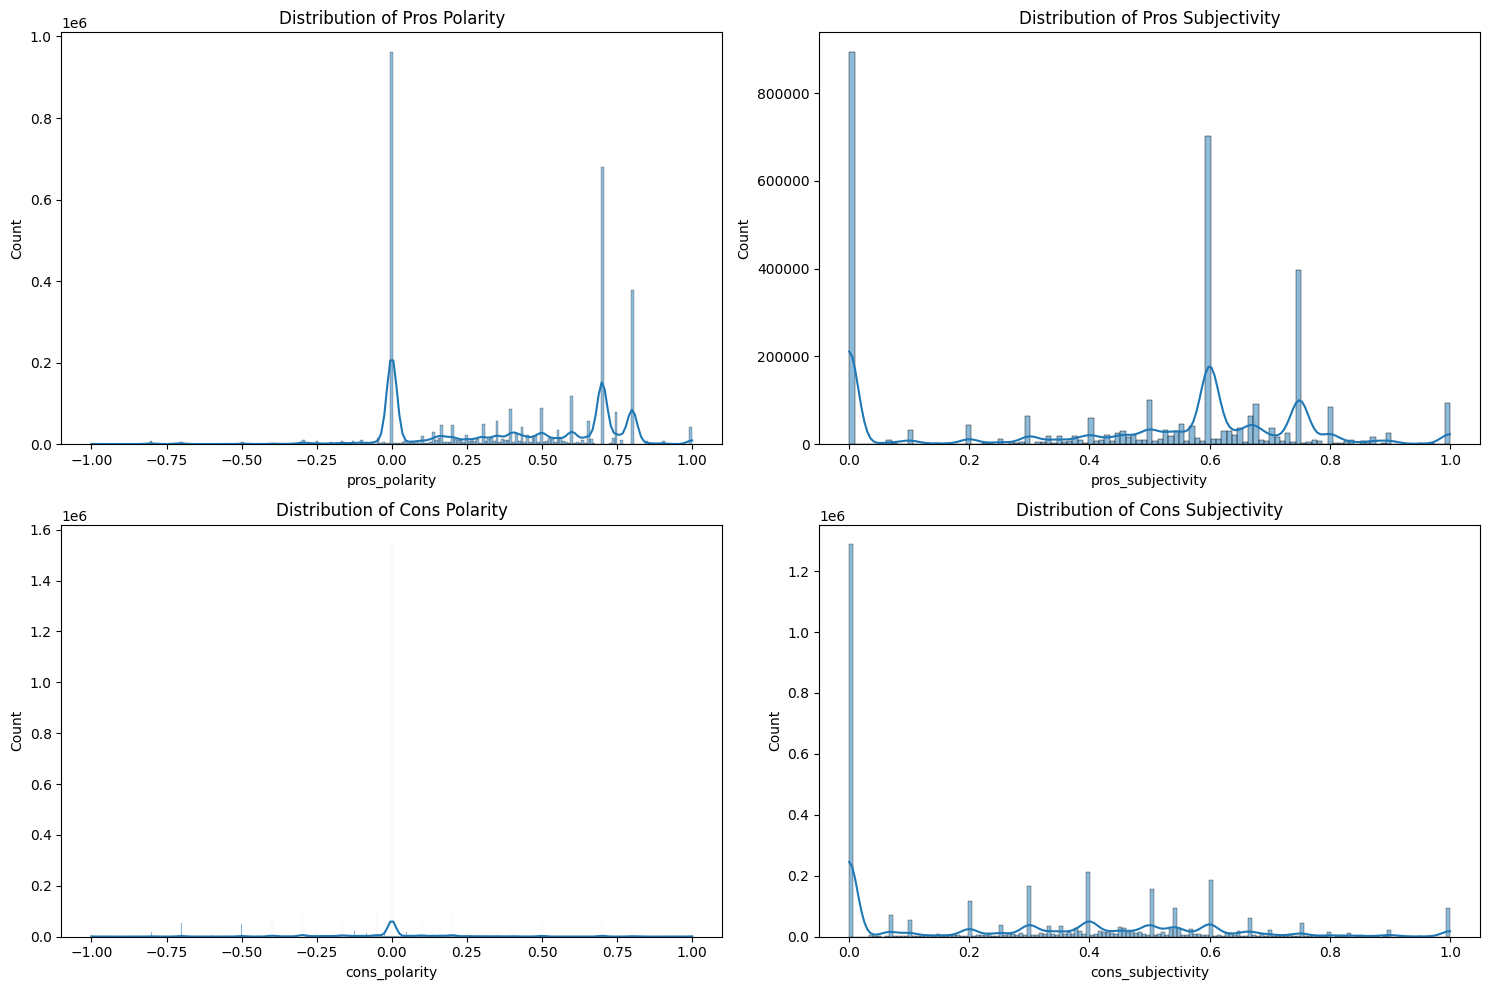

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.histplot(df_attrition_merged['pros_polarity'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Pros Polarity')

sns.histplot(df_attrition_merged['pros_subjectivity'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribution of Pros Subjectivity')

sns.histplot(df_attrition_merged['cons_polarity'].dropna(), kde=True, ax=axes[2])
axes[2].set_title('Distribution of Cons Polarity')

sns.histplot(df_attrition_merged['cons_subjectivity'].dropna(), kde=True, ax=axes[3])
axes[3].set_title('Distribution of Cons Subjectivity')

plt.tight_layout()
plt.show()

### Sentiment Scores vs. Employee Status

/tmp/ipykernel_8842/46418586.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='current_label', y='pros_polarity', data=df_attrition_merged, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_8842/46418586.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='current_label', y='pros_subjectivity', data=df_attrition_merged, ax=axes[1], palette='coolwarm')
/tmp/ipykernel_8842/46418586.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='current_label', y='cons_polarity', data=df_attrition_merged, ax=axes[2], palette='coolwarm')


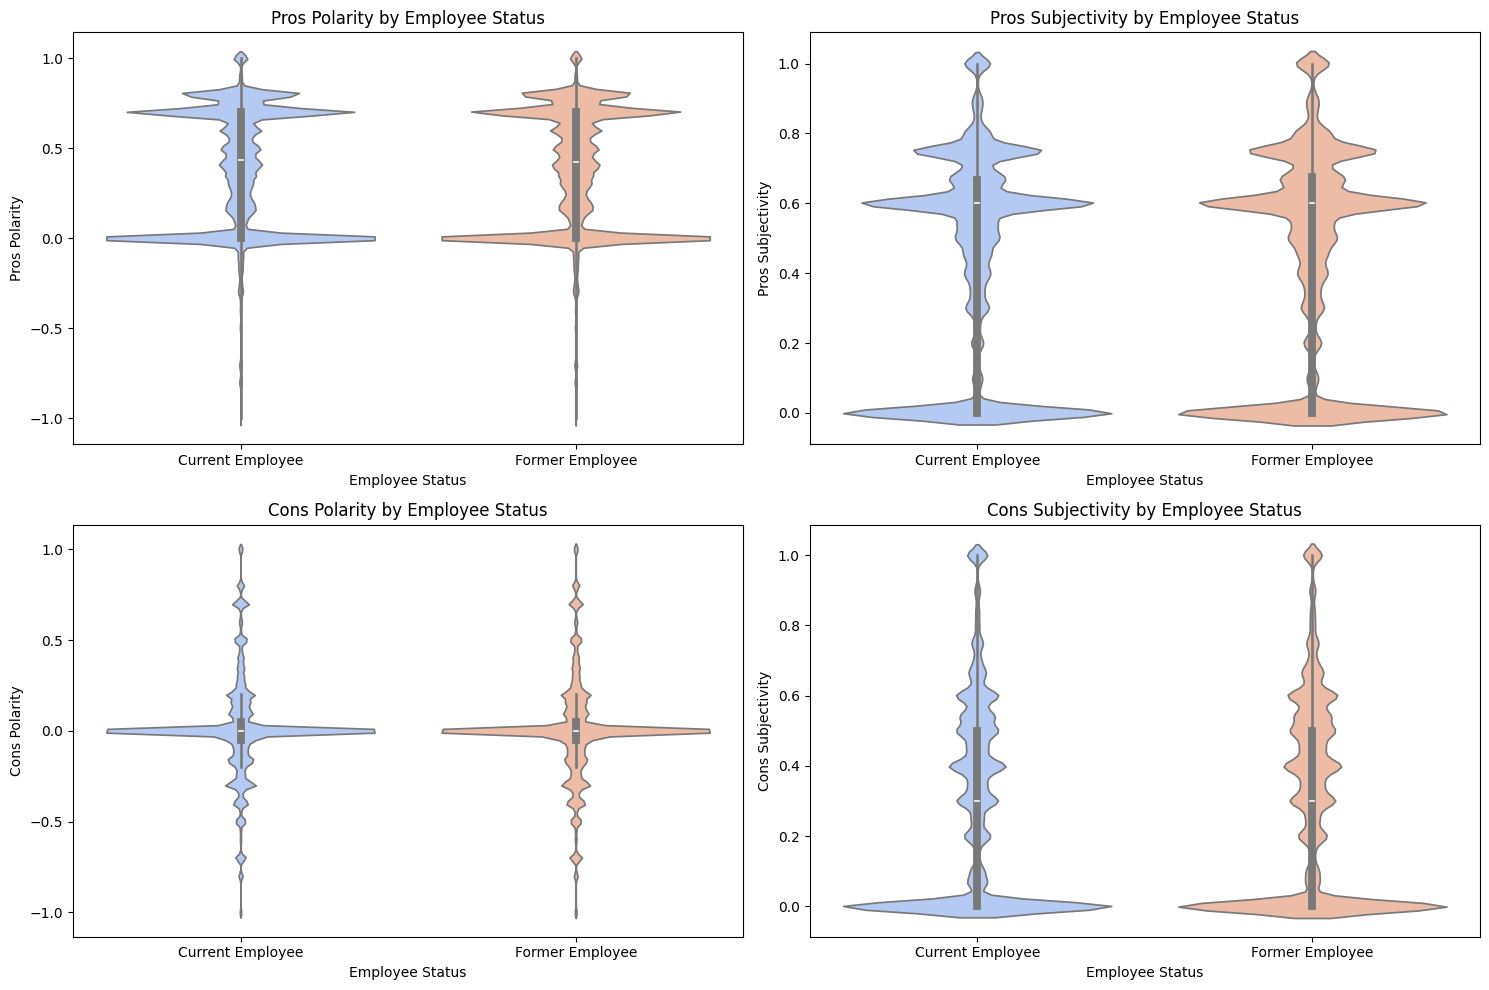

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Map 'current' column for better labels (0: Current, 1: Former)
df_attrition_merged['current_label'] = df_attrition_merged['current'].map({0: 'Current Employee', 1: 'Former Employee'})

# Pros Polarity vs Current Status
sns.violinplot(x='current_label', y='pros_polarity', data=df_attrition_merged, ax=axes[0], palette='coolwarm')
axes[0].set_title('Pros Polarity by Employee Status')
axes[0].set_xlabel('Employee Status')
axes[0].set_ylabel('Pros Polarity')

# Pros Subjectivity vs Current Status
sns.violinplot(x='current_label', y='pros_subjectivity', data=df_attrition_merged, ax=axes[1], palette='coolwarm')
axes[1].set_title('Pros Subjectivity by Employee Status')
axes[1].set_xlabel('Employee Status')
axes[1].set_ylabel('Pros Subjectivity')

# Cons Polarity vs Current Status
sns.violinplot(x='current_label', y='cons_polarity', data=df_attrition_merged, ax=axes[2], palette='coolwarm')
axes[2].set_title('Cons Polarity by Employee Status')
axes[2].set_xlabel('Employee Status')
axes[2].set_ylabel('Cons Polarity')

# Cons Subjectivity vs Current Status
sns.violinplot(x='current_label', y='cons_subjectivity', data=df_attrition_merged, ax=axes[3], palette='coolwarm')
axes[3].set_title('Cons Subjectivity by Employee Status')
axes[3].set_xlabel('Employee Status')
axes[3].set_ylabel('Cons Subjectivity')

plt.tight_layout()
plt.show()

### Correlation between Sentiment Scores and Numerical Ratings

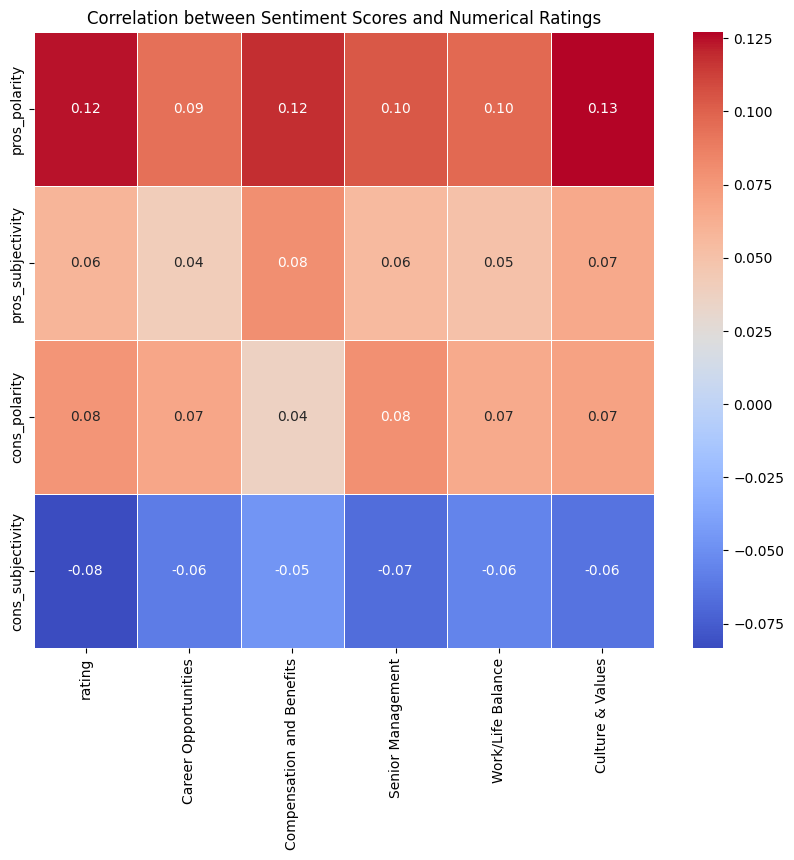

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_cols = ['pros_polarity', 'pros_subjectivity', 'cons_polarity', 'cons_subjectivity']
rating_cols = [
    'rating',
    'Career Opportunities',
    'Compensation and Benefits',
    'Senior Management',
    'Work/Life Balance',
    'Culture & Values'
]

# Ensure all columns exist before selecting
available_sentiment_cols = [col for col in sentiment_cols if col in df_attrition_merged.columns]
available_rating_cols = [col for col in rating_cols if col in df_attrition_merged.columns]

# Create a combined DataFrame for correlation
correlation_df = df_attrition_merged[available_sentiment_cols + available_rating_cols].copy()

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Extract correlations specifically between sentiment and rating columns
sentiment_rating_correlation = correlation_matrix.loc[available_sentiment_cols, available_rating_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(sentiment_rating_correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation between Sentiment Scores and Numerical Ratings')
plt.show()

### Most Frequent Words in Pros and Cons

/tmp/ipykernel_8842/49240621.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=pros_words_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_8842/49240621.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=cons_words_df, ax=axes[1], palette='plasma')


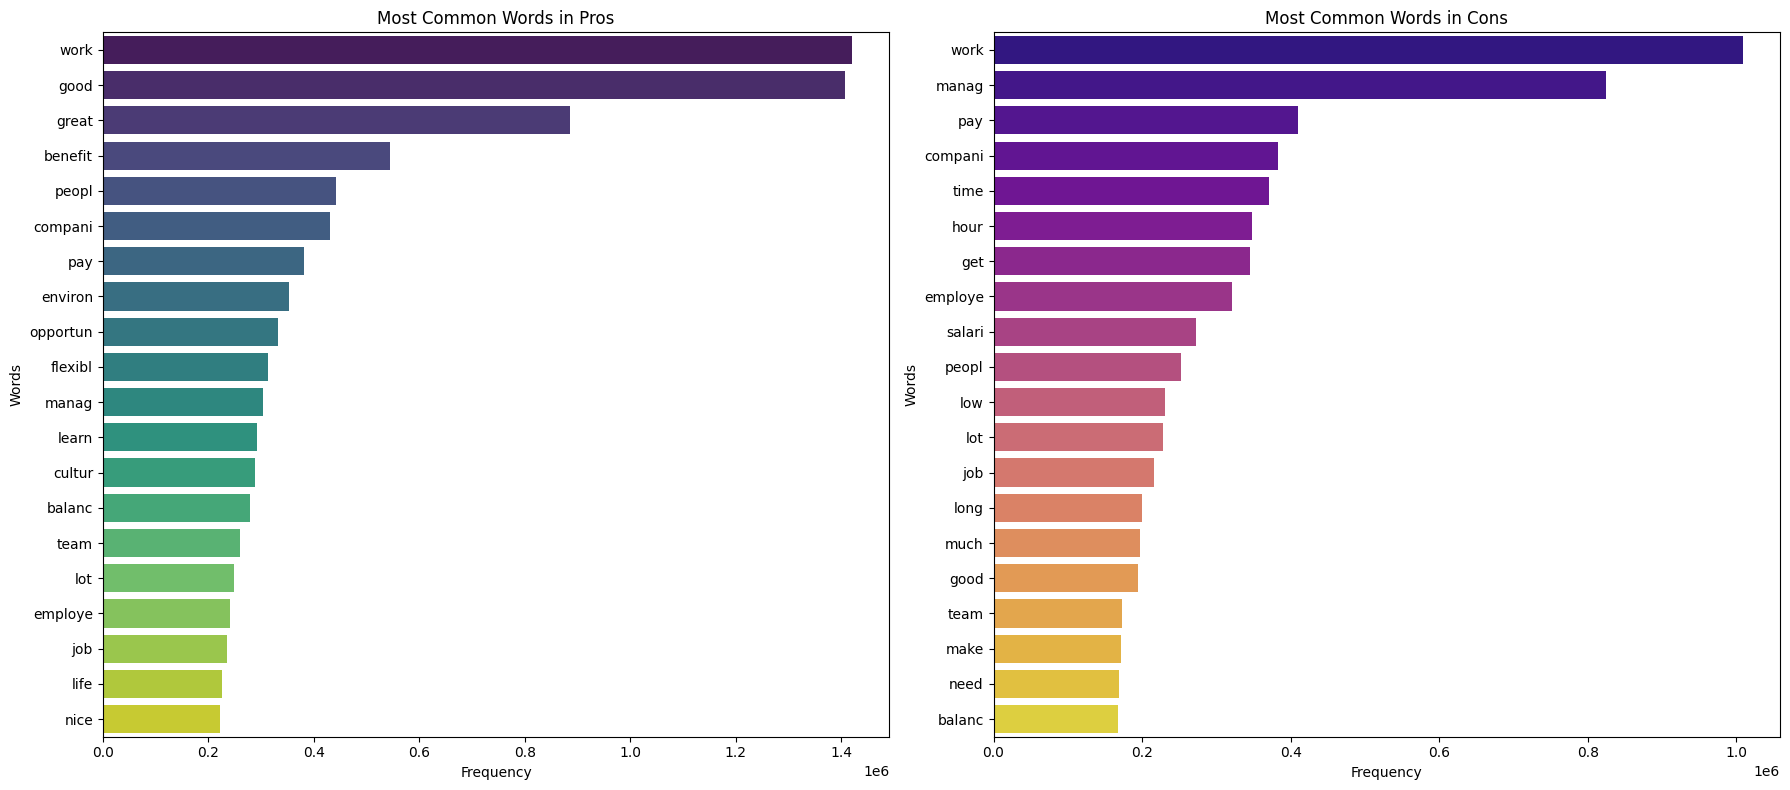

In [39]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def get_most_common_words(text_series, num_words=20):
    all_words = []
    for text in text_series.dropna():
        all_words.extend(text.split())
    return Counter(all_words).most_common(num_words)

# Get most common words for 'pros_processed'
common_pros_words = get_most_common_words(df_attrition_merged['pros_processed'])
common_cons_words = get_most_common_words(df_attrition_merged['cons_processed'])

# Plotting the most common words
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pros words
pros_words_df = pd.DataFrame(common_pros_words, columns=['Word', 'Count'])
sns.barplot(x='Count', y='Word', data=pros_words_df, ax=axes[0], palette='viridis')
axes[0].set_title('Most Common Words in Pros')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Words')

# Cons words
cons_words_df = pd.DataFrame(common_cons_words, columns=['Word', 'Count'])
sns.barplot(x='Count', y='Word', data=cons_words_df, ax=axes[1], palette='plasma')
axes[1].set_title('Most Common Words in Cons')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Words')

plt.tight_layout()
plt.show()

### Word Clouds for Pros and Cons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 19.5 MB/s eta 0:00:00


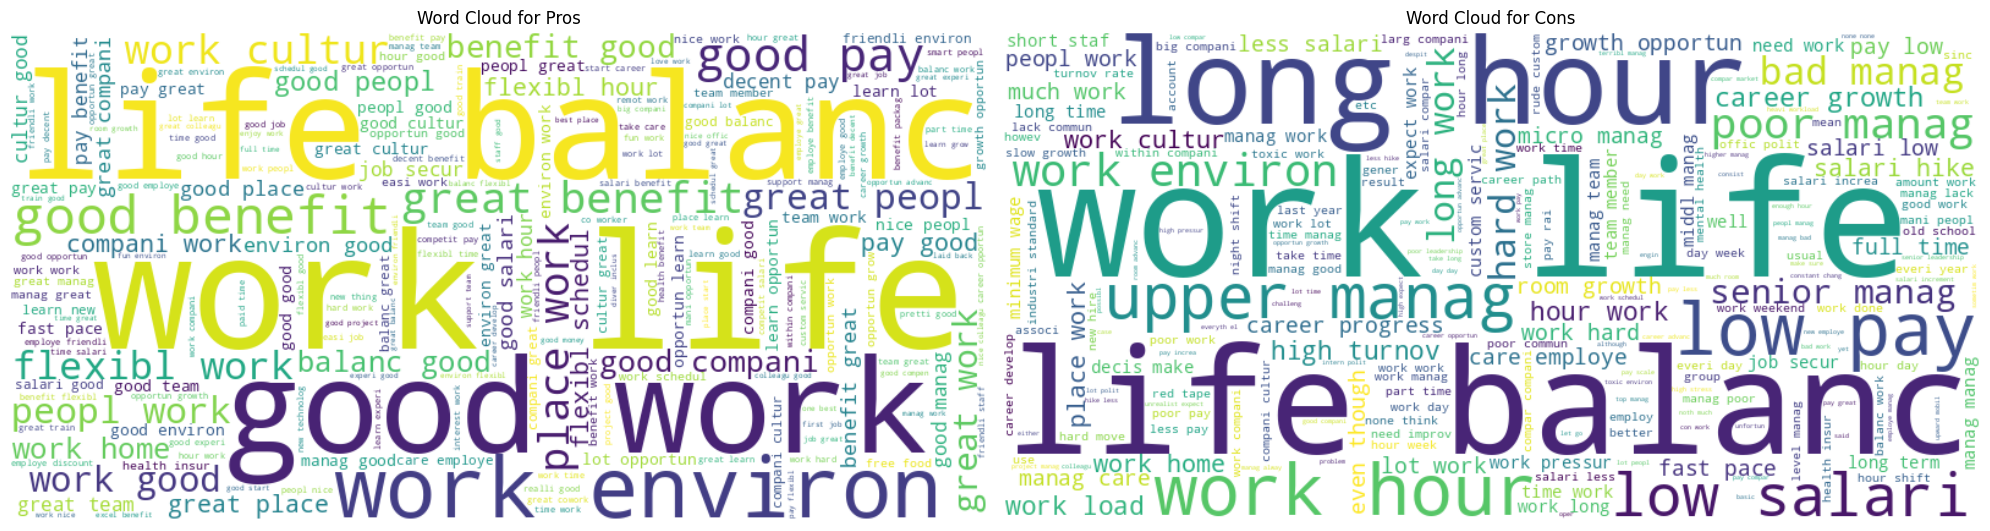

In [40]:
# Install wordcloud library if not already installed
!pip install wordcloud

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

# Join all processed words for 'pros'
pros_text = ' '.join(df_attrition_merged['pros_processed'].dropna())

# Generate a word cloud for 'pros'
wordcloud_pros = WordCloud(width=800, height=400, background_color='white').generate(pros_text)

# Join all processed words for 'cons'
cons_text = ' '.join(df_attrition_merged['cons_processed'].dropna())

# Generate a word cloud for 'cons'
wordcloud_cons = WordCloud(width=800, height=400, background_color='white').generate(cons_text)

# Display the generated image:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(wordcloud_pros, interpolation='bilinear')
axes[0].set_title('Word Cloud for Pros')
axes[0].axis('off')

axes[1].imshow(wordcloud_cons, interpolation='bilinear')
axes[1].set_title('Word Cloud for Cons')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Combined Sentiment Score and Text Length Features

In [41]:
# Create a combined sentiment score (e.g., pros_polarity - cons_polarity)
df_attrition_merged['overall_sentiment'] = df_attrition_merged['pros_polarity'] - df_attrition_merged['cons_polarity']

# Create features for the length of processed 'pros' and 'cons'
df_attrition_merged['pros_length'] = df_attrition_merged['pros_processed'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
df_attrition_merged['cons_length'] = df_attrition_merged['cons_processed'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

print("DataFrame after creating combined sentiment and text length features:")
df_attrition_merged.info()
print("\nSample of new features:")
display(df_attrition_merged[['pros_polarity', 'cons_polarity', 'overall_sentiment', 'pros_length', 'cons_length']].head())

DataFrame after creating combined sentiment and text length features:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 39 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   rating                           float64       
 1   status                           object        
 2   pros                             object        
 3   cons                             object        
 4   Career Opportunities             float64       
 5   Compensation and Benefits        float64       
 6   Senior Management                float64       
 7   Work/Life Balance                float64       
 8   Culture & Values                 float64       
 9   date                             datetime64[ns]
 10  job                              object        
 11  current                          float64       
 12  is_missing_career_opportunities  int64         
 13  is_missing_diversity_i

,pros_polarity,cons_polarity,overall_sentiment,pros_length,cons_length
0,0.8,0.00,0.80,14,7
1,0.0,0.00,0.00,5,5
2,0.0,0.25,-0.25,4,6
3,0.7,0.00,0.70,3,4
5,0.8,0.00,0.80,3,3


In [50]:
import pandas as pd
import os

# Get column names and their data types
column_info = df_attrition_merged.dtypes.reset_index()
column_info.columns = ['Column_Name', 'Data_Type']

# Define output directory and file path
output_dir = './column_info'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'df_attrition_merged_column_info.csv')

# Export to CSV
column_info.to_csv(output_file, index=False)

print(f"Column names and data types exported to: {output_file}")
display(column_info.head())

Column names and data types exported to: ./column_info/df_attrition_merged_column_info.csv


,Column_Name,Data_Type
0,rating,float64
1,status,object
2,pros,object
3,cons,object
4,Career Opportunities,float64


### Creating Interaction Variables

In [43]:
# Create interaction terms between overall_sentiment and key rating columns
df_attrition_merged['sentiment_x_rating'] = df_attrition_merged['overall_sentiment'] * df_attrition_merged['rating']
df_attrition_merged['sentiment_x_career_opp'] = df_attrition_merged['overall_sentiment'] * df_attrition_merged['Career Opportunities']
df_attrition_merged['sentiment_x_comp_benefits'] = df_attrition_merged['overall_sentiment'] * df_attrition_merged['Compensation and Benefits']
df_attrition_merged['sentiment_x_work_life'] = df_attrition_merged['overall_sentiment'] * df_attrition_merged['Work/Life Balance']
df_attrition_merged['sentiment_x_culture_values'] = df_attrition_merged['overall_sentiment'] * df_attrition_merged['Culture & Values']

# Create an interaction term between pros_length and cons_length
df_attrition_merged['pros_len_x_cons_len'] = df_attrition_merged['pros_length'] * df_attrition_merged['cons_length']

print("DataFrame after creating interaction features:")
df_attrition_merged.info()
print("\nSample of new interaction features:")
display(df_attrition_merged[[
    'overall_sentiment', 'rating', 'sentiment_x_rating',
    'Career Opportunities', 'sentiment_x_career_opp',
    'Compensation and Benefits', 'sentiment_x_comp_benefits',
    'Work/Life Balance', 'sentiment_x_work_life',
    'Culture & Values', 'sentiment_x_culture_values',
    'pros_length', 'cons_length', 'pros_len_x_cons_len'
]].head())

DataFrame after creating interaction features:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 45 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   rating                           float64       
 1   status                           object        
 2   pros                             object        
 3   cons                             object        
 4   Career Opportunities             float64       
 5   Compensation and Benefits        float64       
 6   Senior Management                float64       
 7   Work/Life Balance                float64       
 8   Culture & Values                 float64       
 9   date                             datetime64[ns]
 10  job                              object        
 11  current                          float64       
 12  is_missing_career_opportunities  int64         
 13  is_missing_diversity_inclusion   int64       

,overall_sentiment,rating,sentiment_x_rating,Career Opportunities,sentiment_x_career_opp,Compensation and Benefits,sentiment_x_comp_benefits,Work/Life Balance,sentiment_x_work_life,Culture & Values,sentiment_x_culture_values,pros_length,cons_length,pros_len_x_cons_len
0,0.80,5.0,4.00,3.0,2.4,4.0,3.2,3.0,2.4,5.0,4.00,14,7,98
1,0.00,4.0,0.00,3.0,0.0,3.0,0.0,2.0,0.0,4.0,0.00,5,5,25
2,-0.25,3.0,-0.75,4.0,-1.0,4.0,-1.0,2.0,-0.5,3.0,-0.75,4,6,24
3,0.70,4.0,2.80,4.0,2.8,3.0,2.1,4.0,2.8,5.0,3.50,3,4,12
5,0.80,4.0,3.20,3.0,2.4,5.0,4.0,4.0,3.2,4.0,3.20,3,3,9


### Creating Polynomial Features

In [44]:
from sklearn.preprocessing import PolynomialFeatures

# Select numerical columns for polynomial features
# Exclude binary indicators and already created interaction terms to avoid redundancy
polynomial_features_cols = [
    'rating',
    'Career Opportunities',
    'Compensation and Benefits',
    'Senior Management',
    'Work/Life Balance',
    'Culture & Values',
    'overall_sentiment',
    'pros_length',
    'cons_length'
]

# Ensure all selected columns exist in the DataFrame
existing_poly_cols = [col for col in polynomial_features_cols if col in df_attrition_merged.columns]

if existing_poly_cols:
    # Impute NaN values in the selected columns with 0 before applying PolynomialFeatures
    # This is necessary because PolynomialFeatures does not natively handle NaNs.
    # Using 0 for sentiment-related NaNs implies a neutral sentiment when text is missing.
    df_attrition_merged[existing_poly_cols] = df_attrition_merged[existing_poly_cols].fillna(0)

    # Initialize PolynomialFeatures with degree 2 to capture quadratic and interaction terms
    poly = PolynomialFeatures(degree=2, include_bias=False)

    # Fit and transform the selected columns
    poly_features = poly.fit_transform(df_attrition_merged[existing_poly_cols])

    # Create a DataFrame with the new polynomial features
    poly_feature_names = poly.get_feature_names_out(existing_poly_cols)
    df_poly_features = pd.DataFrame(poly_features, columns=poly_feature_names, index=df_attrition_merged.index)

    # Add the new polynomial features to the main DataFrame
    df_attrition_merged = pd.concat([df_attrition_merged, df_poly_features], axis=1)

    print("DataFrame after creating polynomial features:")
    df_attrition_merged.info()
    print("\nSample of new polynomial features:")
    # Display a few of the newly created columns
    display(df_attrition_merged[poly_feature_names].head())
else:
    print("No suitable columns found for creating polynomial features.")

DataFrame after creating polynomial features:
<class 'pandas.core.frame.DataFrame'>
Index: 3499739 entries, 0 to 5872204
Data columns (total 99 columns):
 #   Column                                          Dtype         
---  ------                                          -----         
 0   rating                                          float64       
 1   status                                          object        
 2   pros                                            object        
 3   cons                                            object        
 4   Career Opportunities                            float64       
 5   Compensation and Benefits                       float64       
 6   Senior Management                               float64       
 7   Work/Life Balance                               float64       
 8   Culture & Values                                float64       
 9   date                                            datetime64[ns]
 10  job                      

,rating,rating,Career Opportunities,Career Opportunities,Compensation and Benefits,Compensation and Benefits,Senior Management,Senior Management,Work/Life Balance,Work/Life Balance,...,Culture & Values^2,Culture & Values overall_sentiment,Culture & Values pros_length,Culture & Values cons_length,overall_sentiment^2,overall_sentiment pros_length,overall_sentiment cons_length,pros_length^2,pros_length cons_length,cons_length^2
0,5.0,5.0,3.0,3.0,4.0,4.0,5.0,5.0,3.0,3.0,...,25.0,4.00,70.0,35.0,0.6400,11.2,5.6,196.0,98.0,49.0
1,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,...,16.0,0.00,20.0,20.0,0.0000,0.0,0.0,25.0,25.0,25.0
2,3.0,3.0,4.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0,...,9.0,-0.75,12.0,18.0,0.0625,-1.0,-1.5,16.0,24.0,36.0
3,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,...,25.0,3.50,15.0,20.0,0.4900,2.1,2.8,9.0,12.0,16.0
5,4.0,4.0,3.0,3.0,5.0,5.0,3.0,3.0,4.0,4.0,...,16.0,3.20,12.0,12.0,0.6400,2.4,2.4,9.0,9.0,9.0


### Feature Selection using ANOVA F-values

In [62]:
from sklearn.feature_selection import SelectKBest, f_classif

# Drop non-numeric columns and the target variable to create the feature set X
X = df_attrition_merged.select_dtypes(include=np.number).drop(columns=['current'])

# Impute any remaining NaN values in X with 0. This is necessary for SelectKBest.
X = X.fillna(0)

# Identify and drop features that were previously identified as constant (resulting in NaN F-scores)
# This prevents 'UserWarning: Features are constant.' and 'RuntimeWarning: invalid value encountered in divide'
nan_fscore_features_to_drop = ['is_missing_career_opportunities'] # Explicitly list constant features identified previously
X = X.drop(columns=[col for col in nan_fscore_features_to_drop if col in X.columns], errors='ignore')

# The target variable y
y = df_attrition_merged['current']

# Initialize SelectKBest with f_classif (ANOVA F-value)
# We'll select all features initially to get their scores, then sort.
k_best_selector = SelectKBest(score_func=f_classif, k='all')

# Fit the model to the data
k_best_selector.fit(X, y)

# Get the scores and p-values
f_scores = k_best_selector.scores_
p_values = k_best_selector.pvalues_

# Create a DataFrame to display the results
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'P-Value': p_values
})

# Sort the features by F-Score in descending order
feature_scores = feature_scores.sort_values(by='F-Score', ascending=False)

print("Feature selection results based on ANOVA F-values:")
display(feature_scores.head(10))
print("\nFeatures with lowest P-values (most significant correlations with target):")
display(feature_scores.sort_values(by='P-Value', ascending=True).head(10))

Feature selection results based on ANOVA F-values:


,Feature,F-Score,P-Value
49,rating Culture & Values,148505.477909,0.0
45,rating Career Opportunities,148340.942792,0.0
57,Career Opportunities Culture & Values,145327.051238,0.0
47,rating Senior Management,141491.514855,0.0
55,Career Opportunities Senior Management,140337.654036,0.0
35,rating,137973.094896,0.0
0,rating,137973.094896,0.0
70,Senior Management Culture & Values,133627.141845,0.0
44,rating^2,133489.972842,0.0
5,Culture & Values,124108.782283,0.0



Features with lowest P-values (most significant correlations with target):


,Feature,F-Score,P-Value
49,rating Culture & Values,148505.477909,0.0
45,rating Career Opportunities,148340.942792,0.0
57,Career Opportunities Culture & Values,145327.051238,0.0
47,rating Senior Management,141491.514855,0.0
55,Career Opportunities Senior Management,140337.654036,0.0
35,rating,137973.094896,0.0
0,rating,137973.094896,0.0
70,Senior Management Culture & Values,133627.141845,0.0
44,rating^2,133489.972842,0.0
5,Culture & Values,124108.782283,0.0


### Exporting Feature Selection Results to CSV

### Visualizing Distributions of Top Features

Visualizing distributions for the top 5 features: ['rating Culture & Values', 'rating Career Opportunities', 'Career Opportunities Culture & Values', 'rating Senior Management', 'Career Opportunities Senior Management']


/tmp/ipykernel_8842/782881797.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[plot_idx].legend(title='Employee Status')
/tmp/ipykernel_8842/782881797.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[plot_idx].legend(title='Employee Status')
/tmp/ipykernel_8842/782881797.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[plot_idx].legend(title='Employee Status')
/tmp/ipykernel_8842/782881797.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[plot_idx].legend(t

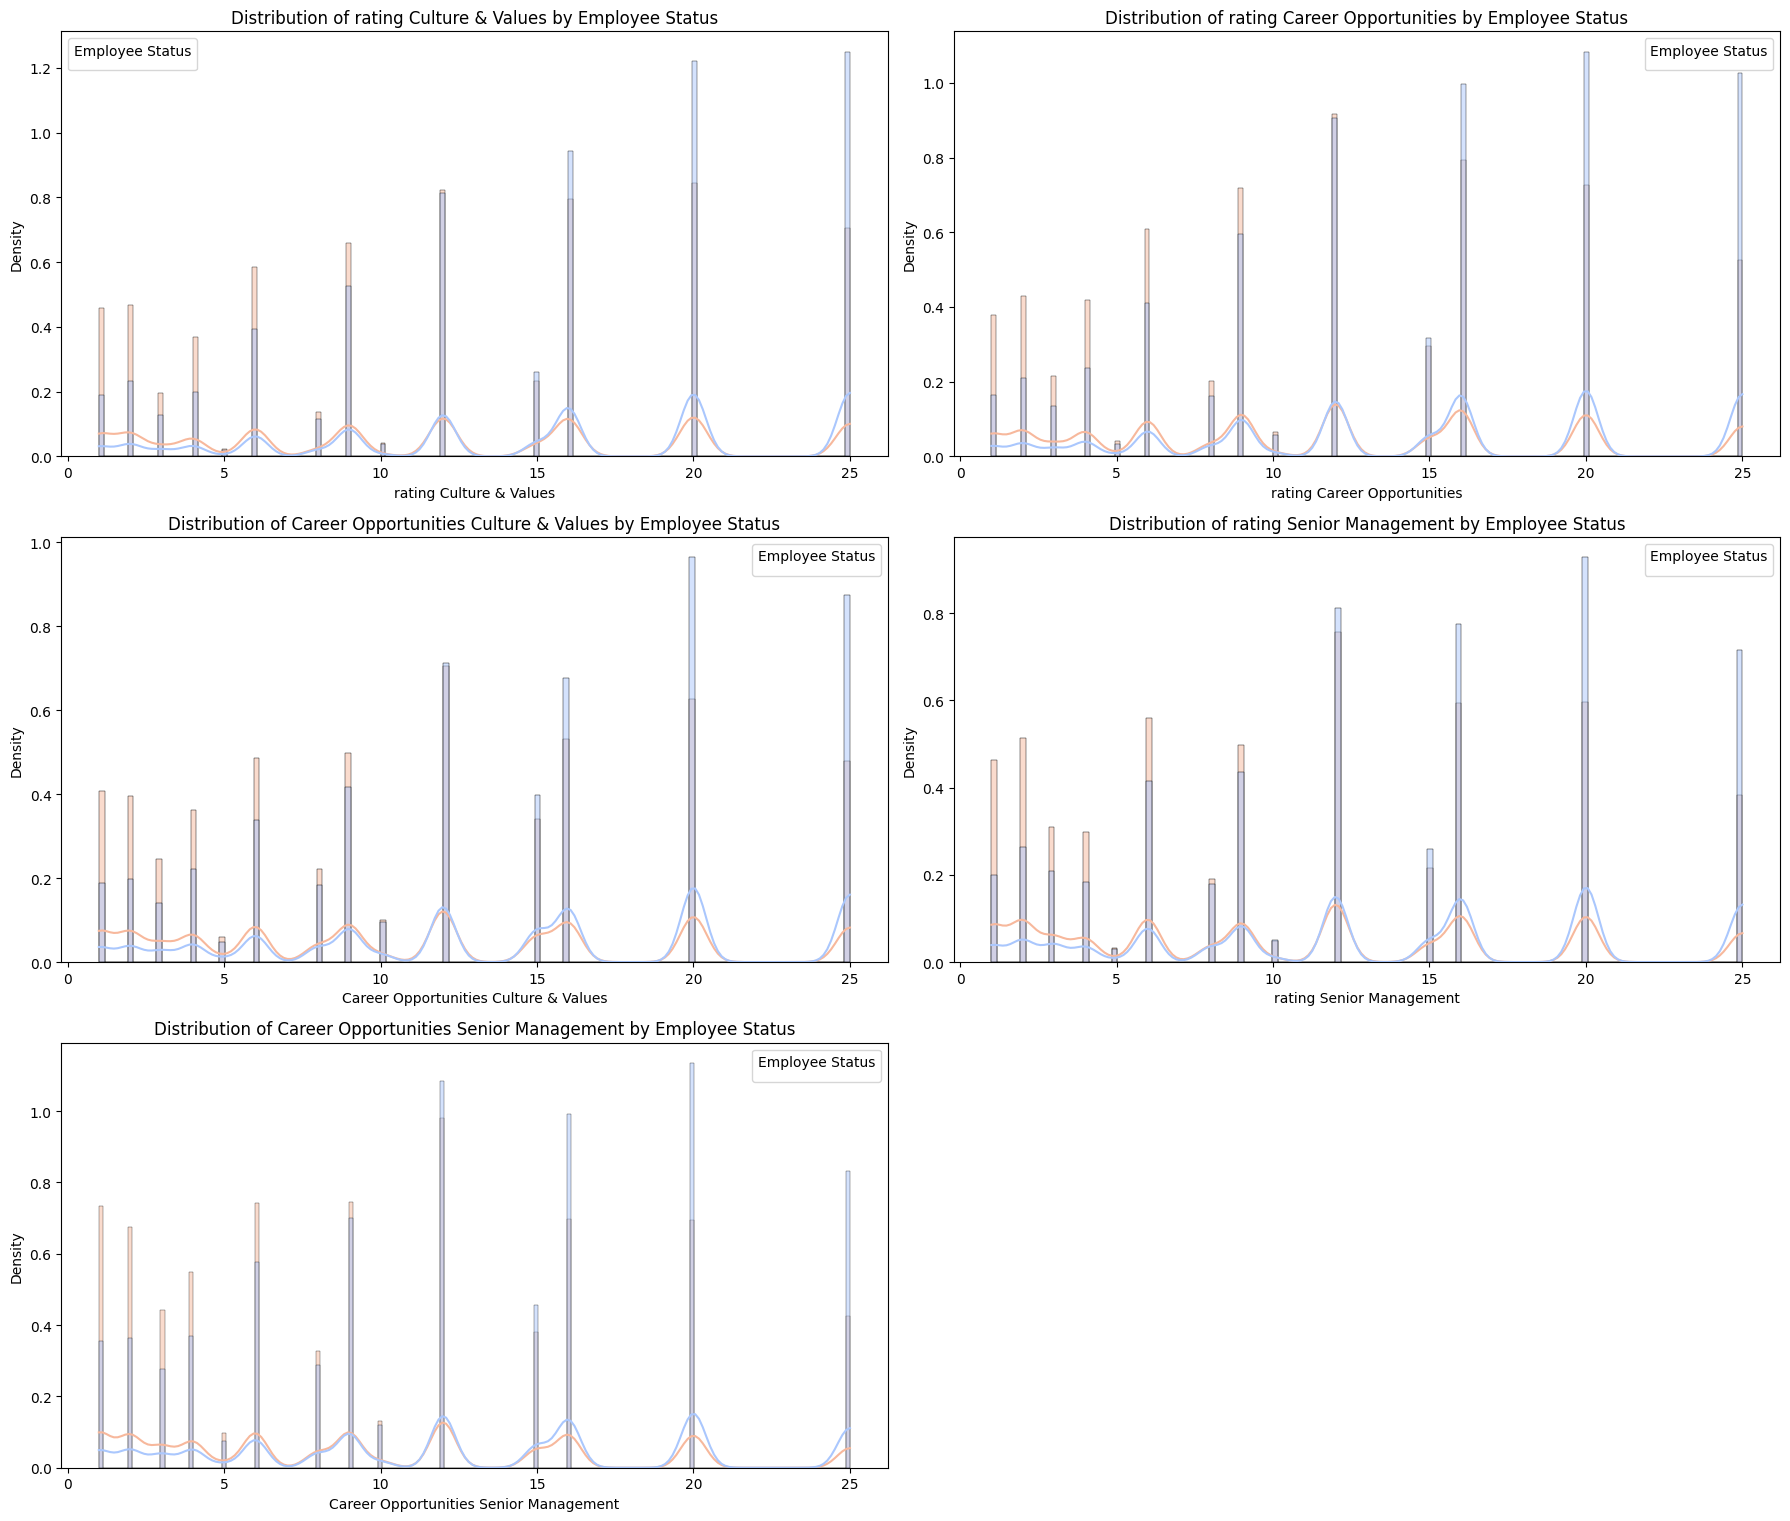

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 features based on F-score
top_n_features = feature_scores['Feature'].head(5).tolist()

# Add 'current' for labeling plots if it's not already in df_attrition_merged, which it should be.
# Ensure 'current_label' is available for clearer visualization.
if 'current_label' not in df_attrition_merged.columns:
    df_attrition_merged['current_label'] = df_attrition_merged['current'].map({0: 'Current Employee', 1: 'Former Employee'})

print(f"Visualizing distributions for the top {len(top_n_features)} features: {top_n_features}")

# Create subplots dynamically
num_plots = len(top_n_features)
fig, axes = plt.subplots(num_plots, 2, figsize=(18, 5 * num_plots))
axes = axes.flatten() # Flatten to easily iterate

plot_idx = 0
for feature in top_n_features:
    if feature not in df_attrition_merged.columns:
        print(f"Warning: Feature '{feature}' not found in DataFrame. Skipping visualization.")
        continue

    # Determine if the feature is numerical (float/int) or categorical (binary int after one-hot encoding)
    # Check if the feature has only two unique values (likely binary or encoded categorical)
    if df_attrition_merged[feature].nunique() <= 5 and df_attrition_merged[feature].dtype == 'int64':
        # Treat as categorical/binary for countplot
        sns.countplot(data=df_attrition_merged, x=feature, hue='current_label', ax=axes[plot_idx], palette='viridis')
        axes[plot_idx].set_title(f'Distribution of {feature} by Employee Status')
        axes[plot_idx].set_ylabel('Count')
        axes[plot_idx].legend(title='Employee Status')
        plot_idx += 1
        if plot_idx < len(axes):
            # Show normalized distribution for the same feature if binary/categorical
            sns.histplot(data=df_attrition_merged, x=feature, hue='current_label', stat='density', common_norm=False, ax=axes[plot_idx], palette='viridis')
            axes[plot_idx].set_title(f'Normalized Distribution of {feature} by Employee Status')
            axes[plot_idx].set_ylabel('Density')
            axes[plot_idx].legend(title='Employee Status')
            plot_idx += 1

    elif pd.api.types.is_numeric_dtype(df_attrition_merged[feature]):
        # Treat as numerical for histplot or kdeplot
        sns.histplot(data=df_attrition_merged, x=feature, hue='current_label', kde=True, stat='density', common_norm=False, ax=axes[plot_idx], palette='coolwarm')
        axes[plot_idx].set_title(f'Distribution of {feature} by Employee Status')
        axes[plot_idx].set_ylabel('Density')
        axes[plot_idx].legend(title='Employee Status')
        plot_idx += 1
    else:
        print(f"Could not determine appropriate plot type for feature '{feature}' (Dtype: {df_attrition_merged[feature].dtype}). Skipping.")

# Hide any unused subplots
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [66]:
print("Descriptive statistics for the top 5 ANOVA selected features:")
display(df_attrition_merged[top_n_features].describe())

Descriptive statistics for the top 5 ANOVA selected features:


,rating Culture & Values,rating Career Opportunities,Career Opportunities Culture & Values,rating Senior Management,Career Opportunities Senior Management
count,3.499739e+06,3.499739e+06,3.499739e+06,3.499739e+06,3.499739e+06
mean,1.368347e+01,1.309941e+01,1.283840e+01,1.216652e+01,1.143712e+01
std,7.586393e+00,7.227108e+00,7.431278e+00,7.370405e+00,7.199127e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,8.000000e+00,8.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00
50%,1.500000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01
75%,2.000000e+01,2.000000e+01,2.000000e+01,2.000000e+01,1.600000e+01
max,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01


In [67]:
output_dir_stats = './feature_statistics'
os.makedirs(output_dir_stats, exist_ok=True)

descriptive_stats = df_attrition_merged[top_n_features].describe()
output_file_stats = os.path.join(output_dir_stats, 'anova_top5_feature_descriptive_stats.csv')
descriptive_stats.to_csv(output_file_stats)

print(f"Descriptive statistics for top 5 ANOVA features exported to: {output_file_stats}")

Descriptive statistics for top 5 ANOVA features exported to: ./feature_statistics/anova_top5_feature_descriptive_stats.csv


In [63]:
import os

output_dir = './feature_selection_results'
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, 'anova_feature_scores.csv')

feature_scores.to_csv(output_file, index=False)

print(f"Feature selection results exported to: {output_file}")

Feature selection results exported to: ./feature_selection_results/anova_feature_scores.csv


### Data Dictionary for Original Pre-cleaned DataFrame

In [51]:
# Re-creating the original df_attrition_merged from df_attrition_list
# This assumes df_attrition_list is still available and contains the original uncleaned dataframes

# NOTE: This cell assumes `df_attrition_list` and `directory_path` from the initial data loading cell are still in scope.
# If not, you might need to re-run the initial data loading and merging cells to populate `df_attrition_list`.

# Initialize an empty list to store individual DataFrames for the original merge
original_df_attrition_list = []

# Filter for CSV files
# NOTE: `files_in_github_repo` should be available from earlier execution
csv_files = [f for f in files_in_github_repo if f.endswith('.csv')]

# Loop through each CSV file, read it, and append to the list
for file_name in csv_files:
    file_path = os.path.join(directory_path, file_name)
    try:
        df_original = pd.read_csv(file_path, low_memory=False) # Added low_memory=False
        original_df_attrition_list.append(df_original)
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

df_attrition_merged_original = pd.concat(original_df_attrition_list, ignore_index=True)

# Get column names and their data types for the original DataFrame
data_dictionary_original = df_attrition_merged_original.dtypes.reset_index()
data_dictionary_original.columns = ['Column_Name', 'Data_Type']

# Define output directory and file path
output_dir = './data_dictionaries'
os.makedirs(output_dir, exist_ok=True)
output_file_original = os.path.join(output_dir, 'data_dictionary_original.csv')

# Export to CSV
data_dictionary_original.to_csv(output_file_original, index=False)

print(f"Data dictionary for original DataFrame exported to: {output_file_original}")
display(data_dictionary_original.head())

Data dictionary for original DataFrame exported to: ./data_dictionaries/data_dictionary_original.csv


,Column_Name,Data_Type
0,rating,float64
1,title,object
2,status,object
3,pros,object
4,cons,object


In [53]:
# Get column names, their data types, and observation counts for the original DataFrame
data_dictionary_original = df_attrition_merged_original.dtypes.reset_index()
data_dictionary_original.columns = ['Column_Name', 'Data_Type']
data_dictionary_original['Observation_Count'] = df_attrition_merged_original.count().values

# Define output directory and file path
output_dir = './data_dictionaries'
os.makedirs(output_dir, exist_ok=True)
output_file_original = os.path.join(output_dir, 'data_dictionary_original.csv')

# Export to CSV
data_dictionary_original.to_csv(output_file_original, index=False)

print(f"Data dictionary for original DataFrame exported to: {output_file_original}")
display(data_dictionary_original.head())

Data dictionary for original DataFrame exported to: ./data_dictionaries/data_dictionary_original.csv


,Column_Name,Data_Type,Observation_Count
0,rating,float64,5872205
1,title,object,5836958
2,status,object,5872205
3,pros,object,5872198
4,cons,object,5872187


### Data Dictionary for DataFrame After Polynomial Features

In [52]:
# Get column names and their data types for the DataFrame with polynomial features
data_dictionary_polynomial = df_attrition_merged.dtypes.reset_index()
data_dictionary_polynomial.columns = ['Column_Name', 'Data_Type']

# Define output file path
output_dir = './data_dictionaries'
os.makedirs(output_dir, exist_ok=True)
output_file_polynomial = os.path.join(output_dir, 'data_dictionary_polynomial_features.csv')

# Export to CSV
data_dictionary_polynomial.to_csv(output_file_polynomial, index=False)

print(f"Data dictionary for DataFrame with polynomial features exported to: {output_file_polynomial}")
display(data_dictionary_polynomial.head())

Data dictionary for DataFrame with polynomial features exported to: ./data_dictionaries/data_dictionary_polynomial_features.csv


,Column_Name,Data_Type
0,rating,float64
1,status,object
2,pros,object
3,cons,object
4,Career Opportunities,float64


In [54]:
# Get column names, their data types, and observation counts for the DataFrame with polynomial features
data_dictionary_polynomial = df_attrition_merged.dtypes.reset_index()
data_dictionary_polynomial.columns = ['Column_Name', 'Data_Type']
data_dictionary_polynomial['Observation_Count'] = df_attrition_merged.count().values

# Define output file path
output_dir = './data_dictionaries'
os.makedirs(output_dir, exist_ok=True)
output_file_polynomial = os.path.join(output_dir, 'data_dictionary_polynomial_features.csv')

# Export to CSV
data_dictionary_polynomial.to_csv(output_file_polynomial, index=False)

print(f"Data dictionary for DataFrame with polynomial features exported to: {output_file_polynomial}")
display(data_dictionary_polynomial.head())

Data dictionary for DataFrame with polynomial features exported to: ./data_dictionaries/data_dictionary_polynomial_features.csv


,Column_Name,Data_Type,Observation_Count
0,rating,float64,3499739
1,status,object,3499739
2,pros,object,3499739
3,cons,object,3499739
4,Career Opportunities,float64,3499739


### Distribution of the Target Variable (`current`)

,Count,Percentage
current,,
0.0,2054632,58.71
1.0,1445107,41.29


/tmp/ipykernel_8842/528124683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=current_distribution_final.index, y=current_distribution_final['Count'], palette='viridis')


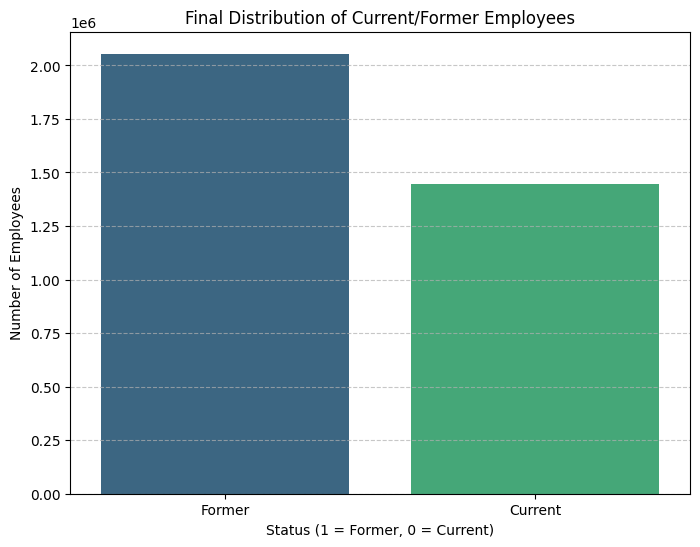

In [55]:
# Calculate value counts and percentages for the 'current' column
current_distribution_final = df_attrition_merged['current'].value_counts().to_frame(name='Count')
current_distribution_final['Percentage'] = (df_attrition_merged['current'].value_counts(normalize=True) * 100).round(2)

display(current_distribution_final)

# Visualize the distribution
fig = plt.figure(figsize=(8, 6))
sns.barplot(x=current_distribution_final.index, y=current_distribution_final['Count'], palette='viridis')
plt.title('Final Distribution of Current/Former Employees')
plt.xlabel('Status (1 = Former, 0 = Current)')
plt.ylabel('Number of Employees')
plt.xticks(ticks=[0, 1], labels=['Former', 'Current'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Correlation of Features with the Target Variable (`current`)

/tmp/ipykernel_8842/1189335464.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_target.values, y=correlations_with_target.index, palette='coolwarm')


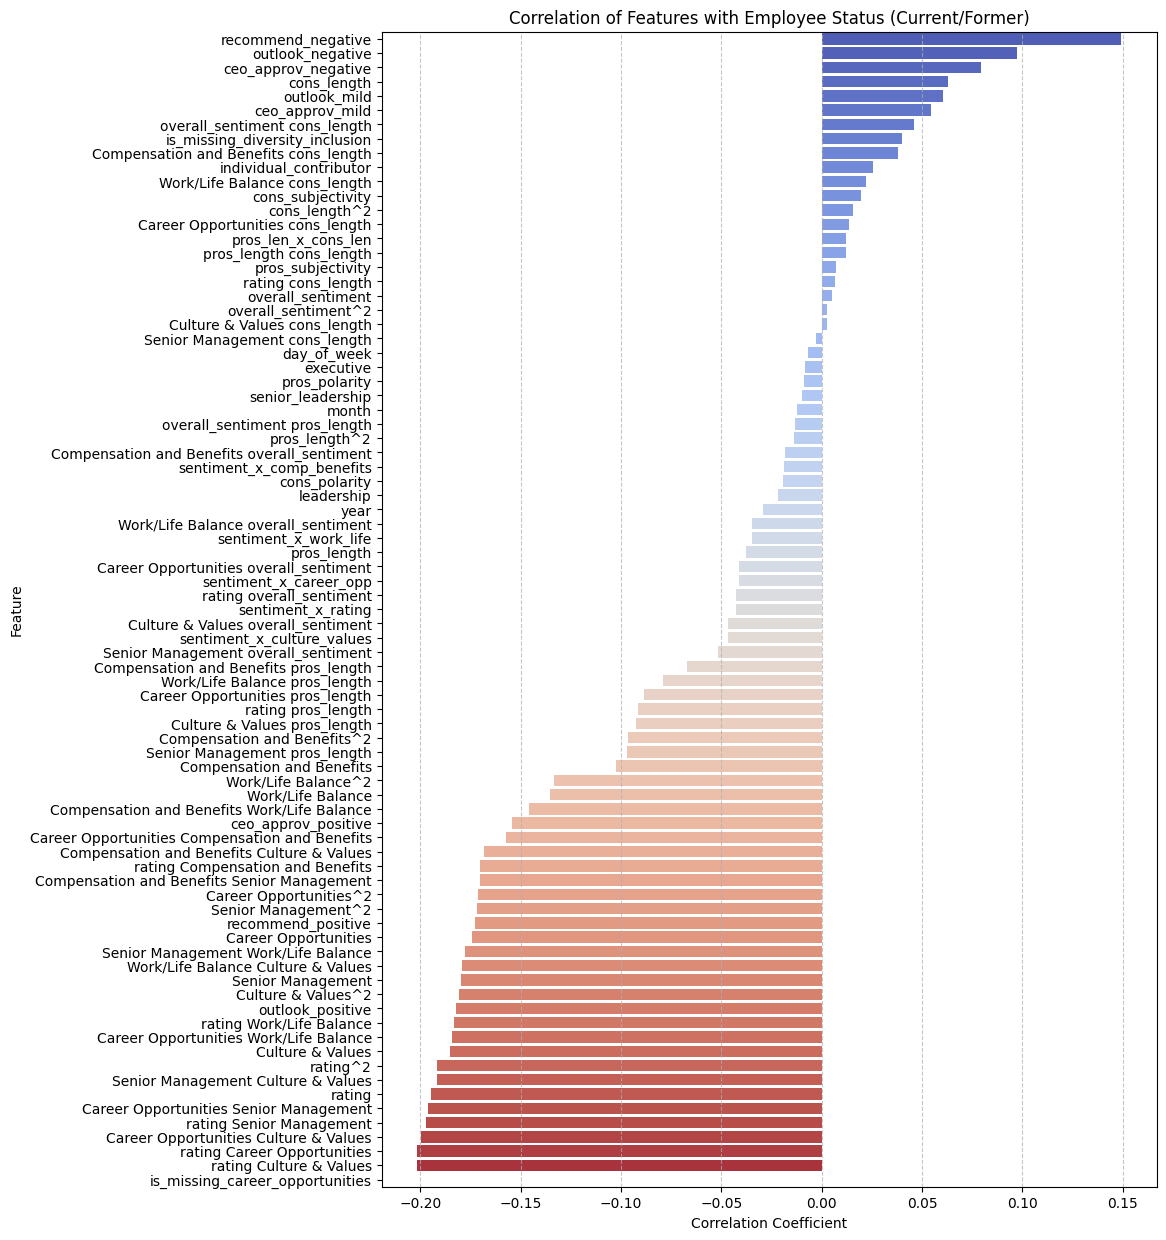

Top 10 positive correlations with 'current' (1=Former, 0=Current):


,current
recommend_negative,0.149265
outlook_negative,0.097352
ceo_approv_negative,0.079573
cons_length,0.063010
cons_length,0.063010
cons_length,0.063010
cons_length,0.063010
outlook_mild,0.060357
ceo_approv_mild,0.054681
overall_sentiment cons_length,0.046057


Top 10 negative correlations with 'current' (1=Former, 0=Current):


,current
rating,-0.194753
rating,-0.194753
rating,-0.194753
rating,-0.194753
Career Opportunities Senior Management,-0.196350
rating Senior Management,-0.197125
Career Opportunities Culture & Values,-0.199674
rating Career Opportunities,-0.201650
rating Culture & Values,-0.201757
is_missing_career_opportunities,NaN


In [56]:
# Identify all numerical columns
numerical_cols_final = df_attrition_merged.select_dtypes(include=np.number).columns.tolist()

# Remove the target variable itself from the feature list for correlation calculation with target
if 'current' in numerical_cols_final:
    numerical_cols_final.remove('current')

# Calculate correlations with the 'current' target variable
correlations_with_target = df_attrition_merged[numerical_cols_final + ['current']].corr()['current'].drop('current')

# Sort for better visualization
correlations_with_target = correlations_with_target.sort_values(ascending=False)

plt.figure(figsize=(10, 15))
sns.barplot(x=correlations_with_target.values, y=correlations_with_target.index, palette='coolwarm')
plt.title('Correlation of Features with Employee Status (Current/Former)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 10 positive correlations with 'current' (1=Former, 0=Current):")
display(correlations_with_target.head(10))

print("Top 10 negative correlations with 'current' (1=Former, 0=Current):")
display(correlations_with_target.tail(10))

### Descriptive Statistics of Key Engineered Features

In [58]:
if 'current_label' in df_attrition_merged.columns:
    df_attrition_merged = df_attrition_merged.drop(columns=['current_label'])
    print("Dropped 'current_label' column.")

Dropped 'current_label' column.


### Feature Correlations for Current vs. Former Employees

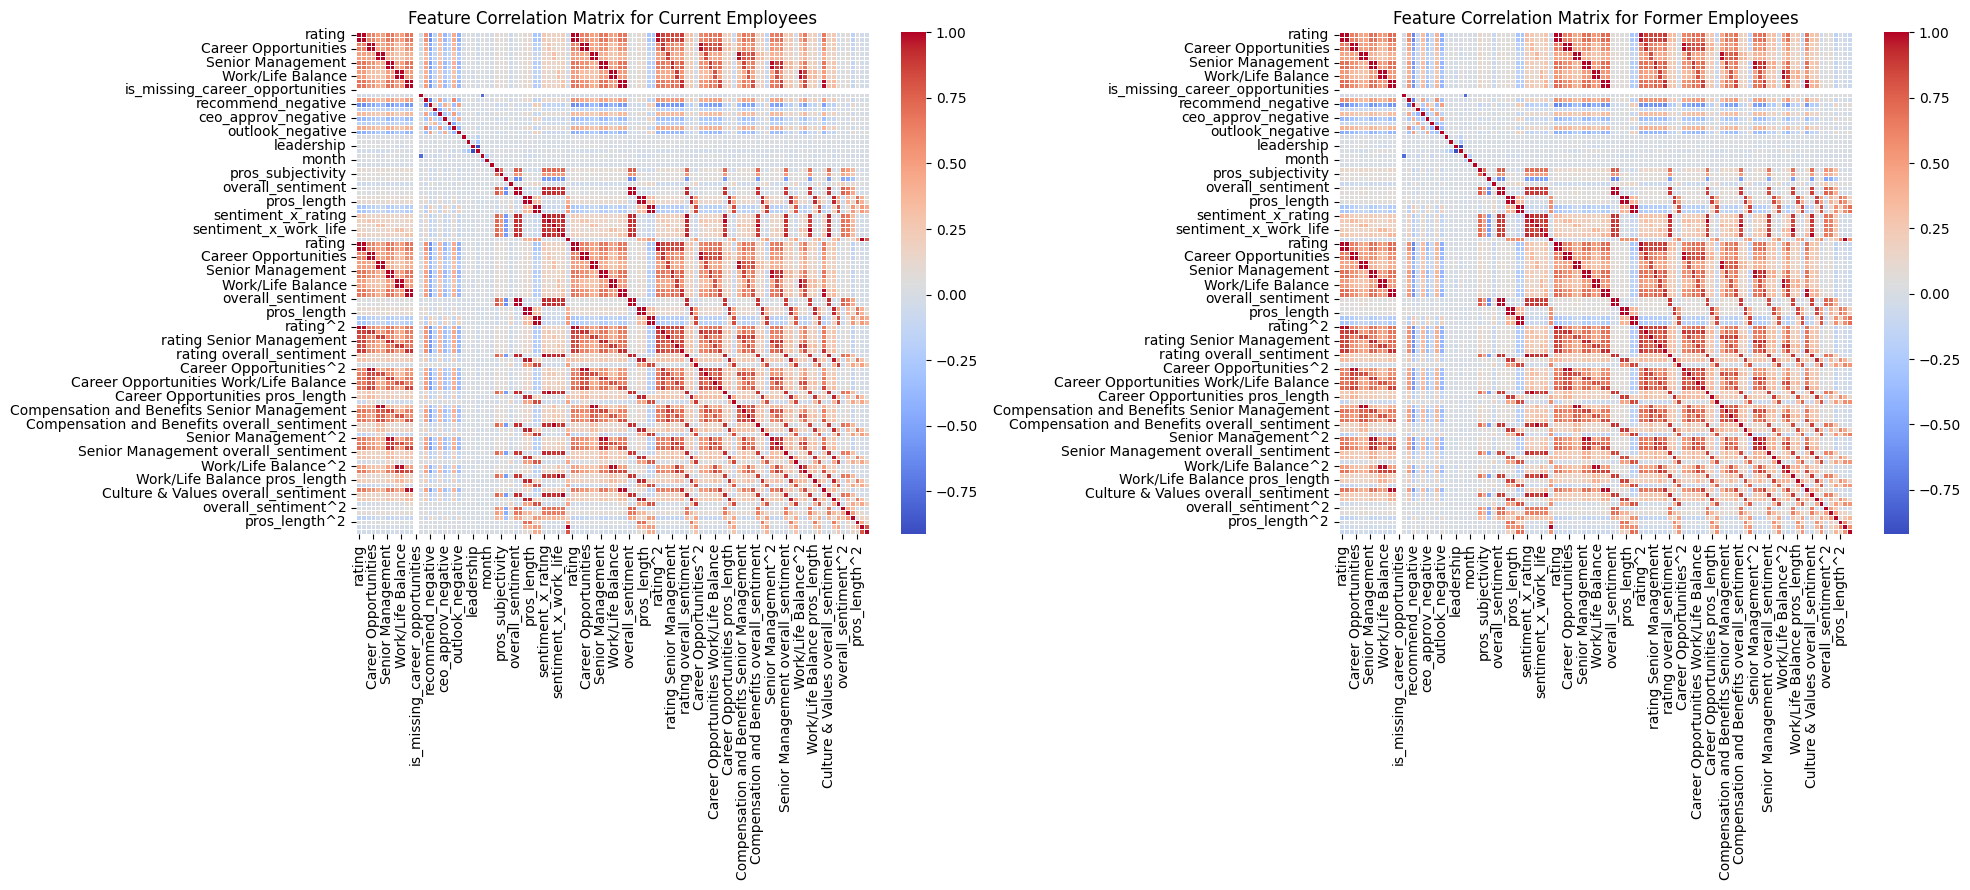

In [59]:
# Separate data into Current Employees (0) and Former Employees (1)
df_current = df_attrition_merged[df_attrition_merged['current'] == 0].copy()
df_former = df_attrition_merged[df_attrition_merged['current'] == 1].copy()

# Identify numerical columns for correlation analysis
numerical_cols_current = df_current.select_dtypes(include=np.number).columns.tolist()
if 'current' in numerical_cols_current:
    numerical_cols_current.remove('current') # Remove 'current' as it's constant within this group

numerical_cols_former = df_former.select_dtypes(include=np.number).columns.tolist()
if 'current' in numerical_cols_former:
    numerical_cols_former.remove('current') # Remove 'current' as it's constant within this group

# Calculate correlation matrices
correlation_matrix_current = df_current[numerical_cols_current].corr()
correlation_matrix_former = df_former[numerical_cols_former].corr()

# Plotting the correlation matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.heatmap(correlation_matrix_current, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix for Current Employees')

sns.heatmap(correlation_matrix_former, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=axes[1])
axes[1].set_title('Feature Correlation Matrix for Former Employees')

plt.tight_layout()
plt.show()

These heatmaps allow for a visual comparison of how features inter-correlate within each group (Current vs. Former employees). Differences in patterns or strengths of correlations can highlight factors that might differentiate between the two groups beyond just their direct correlation with the `current` variable.

In [57]:
# Select a sample of engineered features for descriptive statistics
engineered_features_sample = [
    'overall_sentiment',
    'pros_length',
    'cons_length',
    'sentiment_x_rating', # Interaction term
    'rating^2',           # Polynomial term
    'Career Opportunities^2' # Another polynomial term
]

# Filter for features that actually exist in the DataFrame
existing_engineered_features = [col for col in engineered_features_sample if col in df_attrition_merged.columns]

if existing_engineered_features:
    print("Descriptive statistics for a sample of engineered features:")
    display(df_attrition_merged[existing_engineered_features].describe())
else:
    print("No selected engineered features found in the DataFrame to display statistics.")

Descriptive statistics for a sample of engineered features:


,overall_sentiment,overall_sentiment,pros_length,pros_length,cons_length,cons_length,sentiment_x_rating,rating^2,Career Opportunities^2
count,3.499739e+06,3.499739e+06,3.499739e+06,3.499739e+06,3.499739e+06,3.499739e+06,3.497411e+06,3.499739e+06,3.499739e+06
mean,3.811131e-01,3.811131e-01,7.793762e+00,7.793762e+00,1.021666e+01,1.021666e+01,1.393192e+00,1.424497e+01,1.303094e+01
std,4.276613e-01,4.276613e-01,7.895276e+00,7.895276e+00,1.773656e+01,1.773656e+01,1.685752e+00,7.764475e+00,7.967663e+00
min,-2.000000e+00,-2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+01,1.000000e+00,1.000000e+00
25%,0.000000e+00,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,0.000000e+00,9.000000e+00,9.000000e+00
50%,4.000000e-01,4.000000e-01,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,1.200000e+00,1.600000e+01,1.600000e+01
75%,7.000000e-01,7.000000e-01,8.000000e+00,8.000000e+00,1.000000e+01,1.000000e+01,2.633333e+00,2.500000e+01,1.600000e+01
max,2.000000e+00,2.000000e+00,7.040000e+02,7.040000e+02,3.365000e+03,3.365000e+03,1.000000e+01,2.500000e+01,2.500000e+01
